# โค้ดวิเคราะห์ข้อมูล PM2.5 ของกรมควบคุมมลพิษของสามจังหวัด คือ ลพบุรี สระบุรี และ นครนายก
* ให้ดาวน์โหลด excel จาก https://air4thai.pcd.go.th/webV3/#/History และเลือกข้อมูลรายวัน ทัง 5 ปี 2021-2025
* ให้อัพโหลดไฟล์ excel เพื่อเข้าไปวิเคราะห์
* โปรแกรมจะใช้วิธีการหาจุดสถานีที่อยู่ในพื้นที่สามจังหวัดและอยู่รอบข้างจังหวัดเหล่านั้นด้วยการ buffer ออกไป 25 กิโลเมตร

In [ ]:
# =====================================================================
# PM2.5 AIR4THAI — COMPLETE GOOGLE COLAB WORKFLOW
# Study area: Lop Buri / Saraburi / Nakhon Nayok
# Period: 2021-2025 (BE 2564-2568)
#
# IMPORTANT:
# - Upload the five PCD Air4Thai DAILY PM2.5 24-h Excel workbooks together.
# - This version checks each workbook/year BEFORE analysis.
# - It handles Gregorian dates, Buddhist Era dates, and Excel serial dates.
# - It avoids pivot_table()/pivot()/unstack() because the current Colab
#   runtime showed a pandas reshape-version conflict.
# - Primary provincial exposure = inside-province stations when available;
#   surrounding stations are used only as a fallback and are retained as
#   a sensitivity/network exposure series.
# =====================================================================


# =====================================================================
# CELL 0 — INSTALL
# Run this FIRST in a fresh Colab runtime, before importing pandas.
# =====================================================================
!pip -q install geopandas openpyxl

In [ ]:

# =====================================================================
# CELL 1 — IMPORTS + CONFIGURATION
# =====================================================================
import os
import re
import glob
import calendar
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests

from shapely.geometry import Point
from scipy.stats import kruskal, mannwhitneyu
from google.colab import files

warnings.filterwarnings("ignore")

DATA_DIR = "/content"
OUT_DIR = "/content/pm25_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

STUDY_YEARS = [2021, 2022, 2023, 2024, 2025]

TARGET_PROVINCES = [
    "Lop Buri",
    "Saraburi",
    "Nakhon Nayok"
]

# Canonicalize alternative English spellings in boundary data
TARGET_CANON = {
    "lopburi": "Lop Buri",
    "lopburi province": "Lop Buri",
    "saraburi": "Saraburi",
    "nakhonnayok": "Nakhon Nayok",
    "nakhon nayok": "Nakhon Nayok",
}

BUFFER_KM = 25

# A station-month must contain at least 75% of calendar days
MIN_DAYS_FRAC_MONTH = 0.75

WET_MONTHS = [5, 6, 7, 8, 9, 10]      # May-Oct
DRY_MONTHS = [11, 12, 1, 2, 3, 4]     # Nov-Apr

FIG_DPI = 300

# Stop the workflow if any of the five years is absent
STRICT_YEAR_CHECK = True

METRIC_CRS = "EPSG:32647"  # UTM 47N

def _norm(x):
    return "".join(str(x).lower().split())

print("Target provinces :", TARGET_PROVINCES)
print("Study years      :", STUDY_YEARS)
print("Buffer           :", BUFFER_KM, "km")
print("Monthly QA       :", f">= {MIN_DAYS_FRAC_MONTH*100:.0f}%")
print("Output directory :", OUT_DIR)


# =====================================================================
# CELL 2 — UPLOAD ALL FIVE AIR4THAI EXCEL FILES
# =====================================================================
print("""
Upload the FIVE Air4Thai DAILY PM2.5 24-hour workbooks:
BE 2564 = 2021
BE 2565 = 2022
BE 2566 = 2023
BE 2567 = 2024
BE 2568 = 2025

Select all five files in one upload dialog.
""")

uploaded = files.upload()

print("\nUploaded:")
for name in uploaded:
    print("  ", name)

Target provinces : ['Lop Buri', 'Saraburi', 'Nakhon Nayok']
Study years      : [2021, 2022, 2023, 2024, 2025]
Buffer           : 25 km
Monthly QA       : >= 75%
Output directory : /content/pm25_outputs

Upload the FIVE Air4Thai DAILY PM2.5 24-hour workbooks:
BE 2564 = 2021
BE 2565 = 2022
BE 2566 = 2023
BE 2567 = 2024
BE 2568 = 2025

Select all five files in one upload dialog.



Saving 2021.xlsx to 2021 (1).xlsx
Saving 2022.xlsx to 2022 (1).xlsx
Saving 2023.xlsx to 2023 (1).xlsx
Saving 2024.xlsx to 2024 (1).xlsx
Saving 2025.xlsx to 2025 (1).xlsx

Uploaded:
   2021 (1).xlsx
   2022 (1).xlsx
   2023 (1).xlsx
   2024 (1).xlsx
   2025 (1).xlsx



WORKBOOK INSPECTION

2021 (1).xlsx
  data sheet: PM2.5
  years    : [2021]
  stations : 76
  rows     : 26,721
  rows/year:
    2021: 26,721

2021.xlsx
  data sheet: PM2.5
  years    : [2021]
  stations : 76
  rows     : 26,721
  rows/year:
    2021: 26,721

2022 (1).xlsx
  data sheet: PM2.5
  years    : [2022]
  stations : 86
  rows     : 28,717
  rows/year:
    2022: 28,717

2022.xlsx
  data sheet: PM2.5
  years    : [2022]
  stations : 86
  rows     : 28,717
  rows/year:
    2022: 28,717

2023 (1).xlsx
  data sheet: PM2.5
  years    : [2023]
  stations : 96
  rows     : 31,612
  rows/year:
    2023: 31,612

2023.xlsx
  data sheet: PM2.5
  years    : [2023]
  stations : 96
  rows     : 31,612
  rows/year:
    2023: 31,612

2024 (1).xlsx
  data sheet: Data
  years    : [2024]
  stations : 96
  rows     : 34,420
  rows/year:
    2024: 34,420

2024.xlsx
  data sheet: Data
  years    : [2024]
  stations : 96
  rows     : 34,420
  rows/year:
    2024: 34,420

2025 (1).xlsx
  data sheet: 

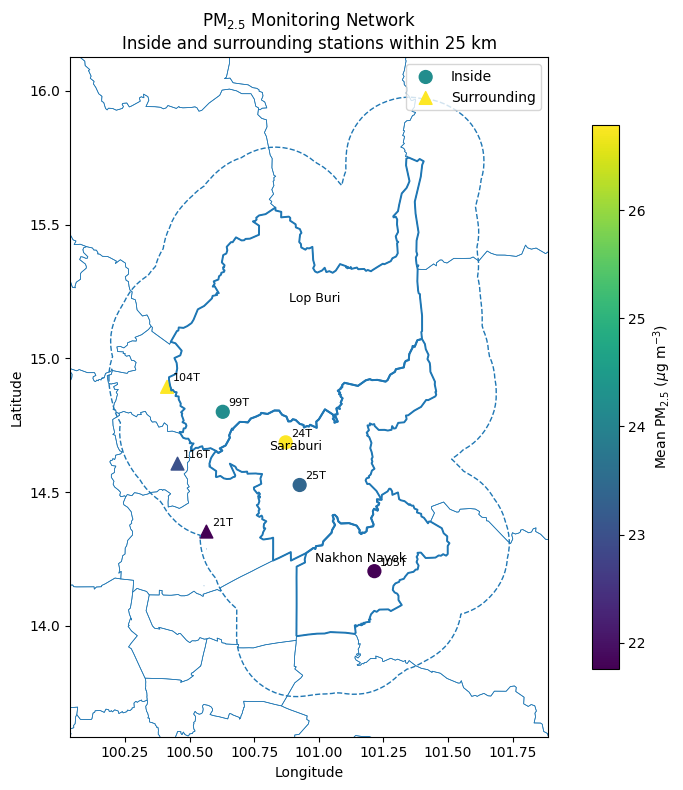

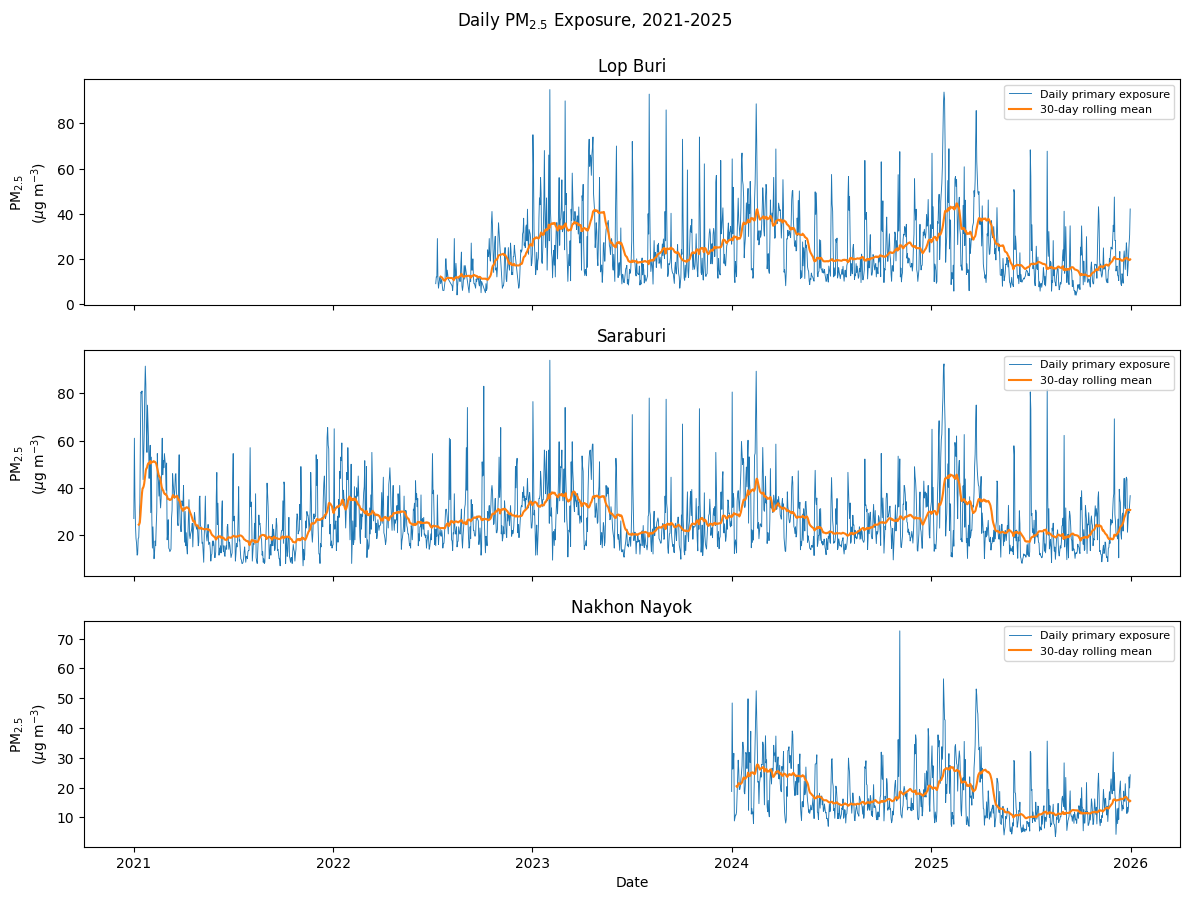


ANNUAL STATISTICS
    province  year   n  mean    sd  median    q1    q3   iqr  min   max   p05   p95
    Lop Buri  2022 147 16.67  8.85   13.00 10.00 23.00 13.00 4.00 42.00  6.00 33.70
    Lop Buri  2023 364 27.45 16.30   22.20 15.60 34.50 18.90 7.00 95.00 10.52 63.37
    Lop Buri  2024 366 26.81 14.26   24.35 14.82 35.70 20.88 8.10 88.70 10.88 53.45
    Lop Buri  2025 365 22.85 15.97   17.20 11.90 29.85 17.95 3.90 93.90  7.62 55.02
Nakhon Nayok  2024 361 19.31  8.91   16.90 12.40 24.90 12.50 7.00 72.60  9.50 35.20
Nakhon Nayok  2025 364 15.48  9.24   12.40  9.10 19.00  9.90 3.60 56.50  5.90 33.70
    Saraburi  2021 364 25.85 15.77   21.50 14.00 32.62 18.62 7.00 91.50  9.00 57.85
    Saraburi  2022 365 28.24 10.95   26.00 20.50 35.00 14.50 8.00 83.00 15.50 49.40
    Saraburi  2023 365 28.14 13.39   24.85 18.35 35.00 16.65 9.40 94.00 13.06 55.00
    Saraburi  2024 366 27.50 11.72   25.08 18.41 33.45 15.04 9.50 89.35 14.15 50.69
    Saraburi  2025 365 25.68 15.43   21.10 15.30 30.30 15

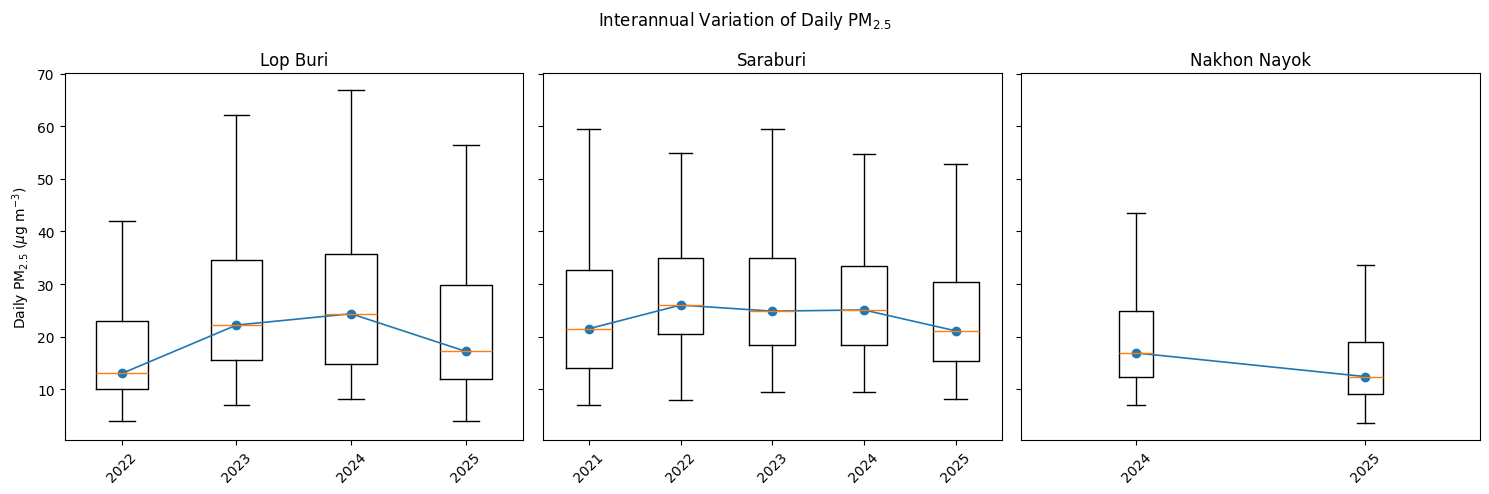

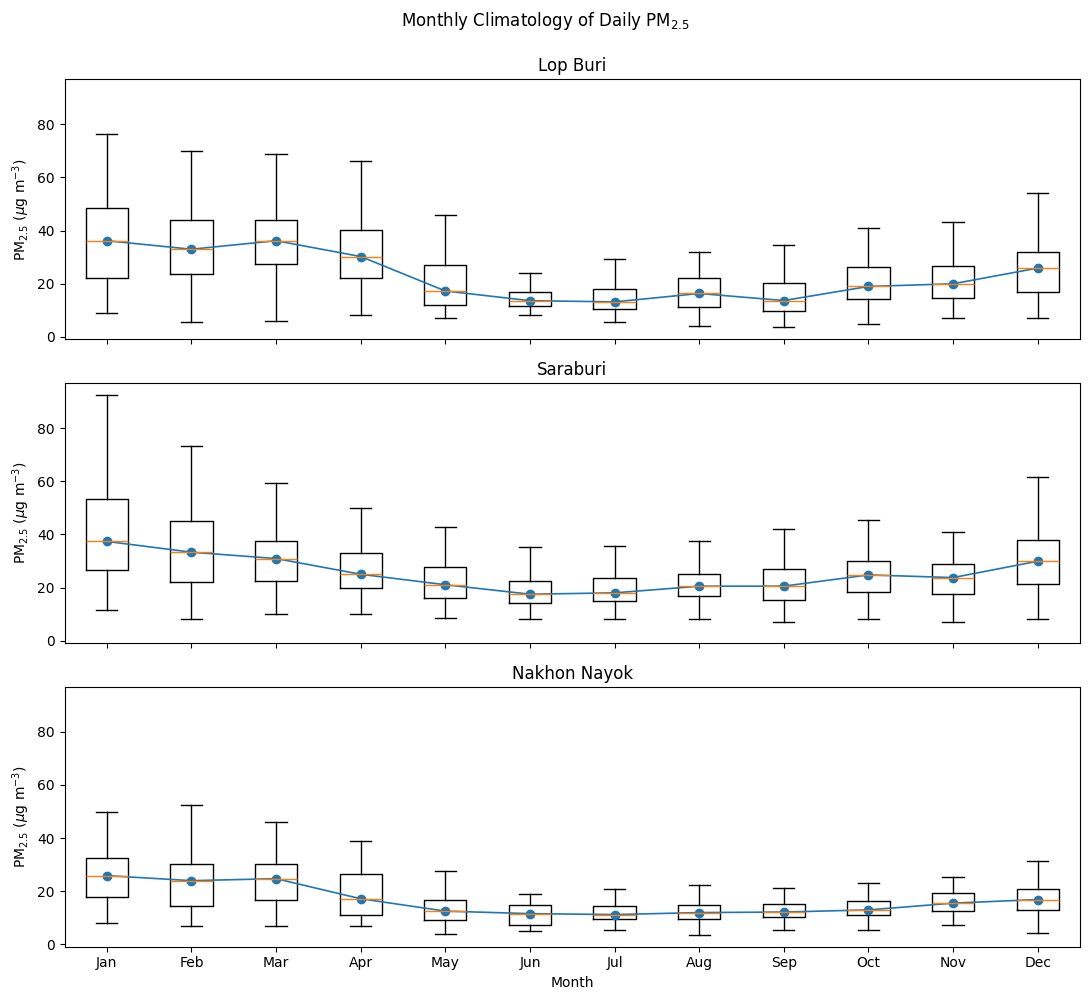

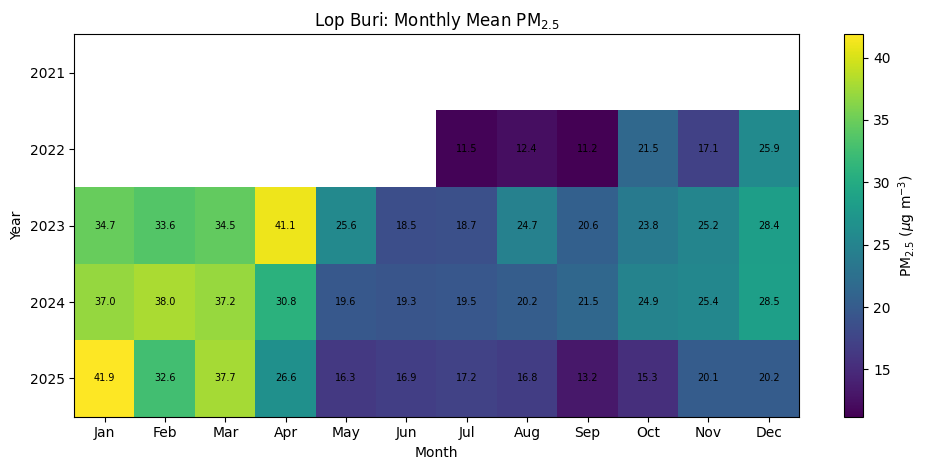

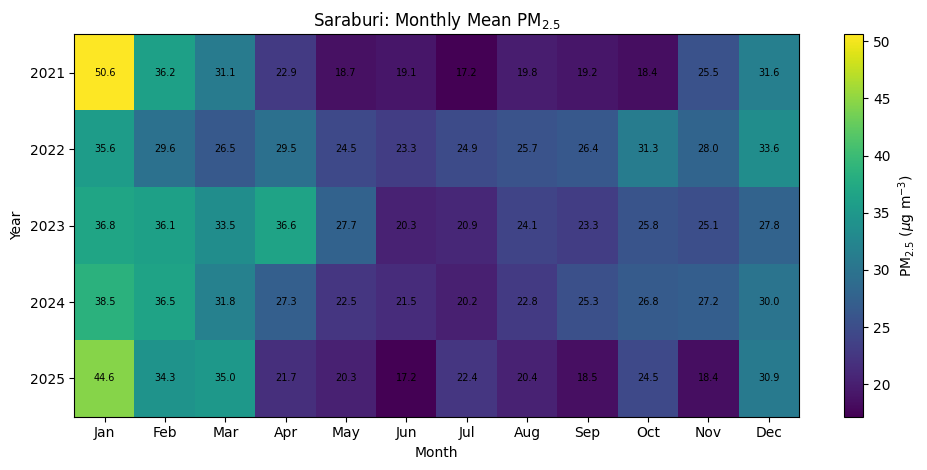

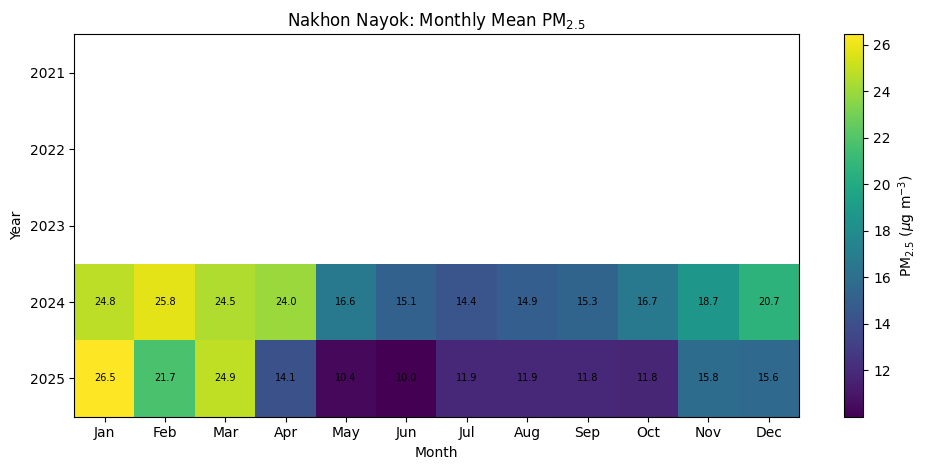

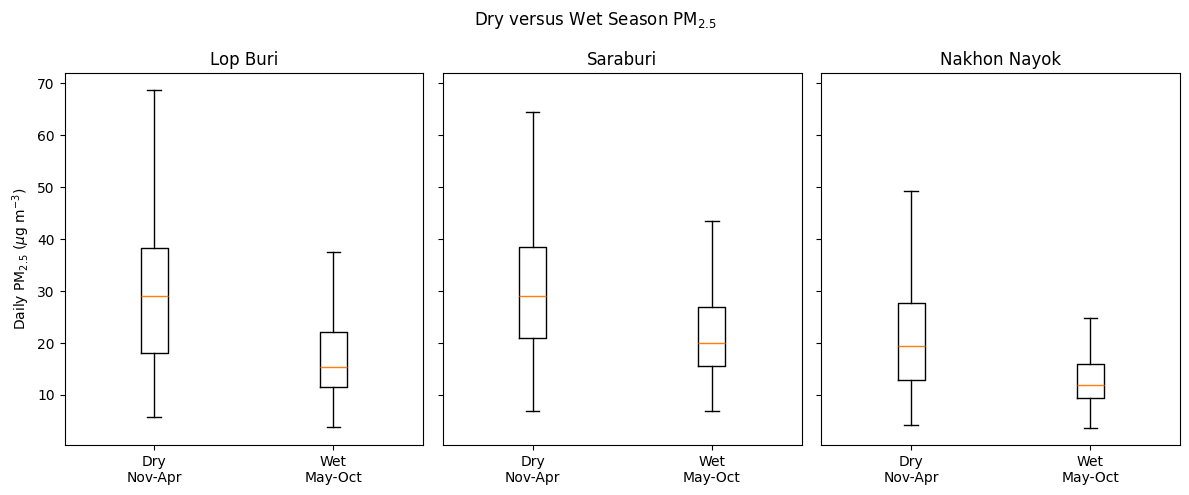


DRY vs WET
    province  dry_n  dry_median  wet_n  wet_median        U   p
    Lop Buri    593        29.1    649        15.3 291421.0 0.0
    Saraburi    906        29.0    919        20.0 592147.5 0.0
Nakhon Nayok    360        19.4    365        12.0  98834.5 0.0


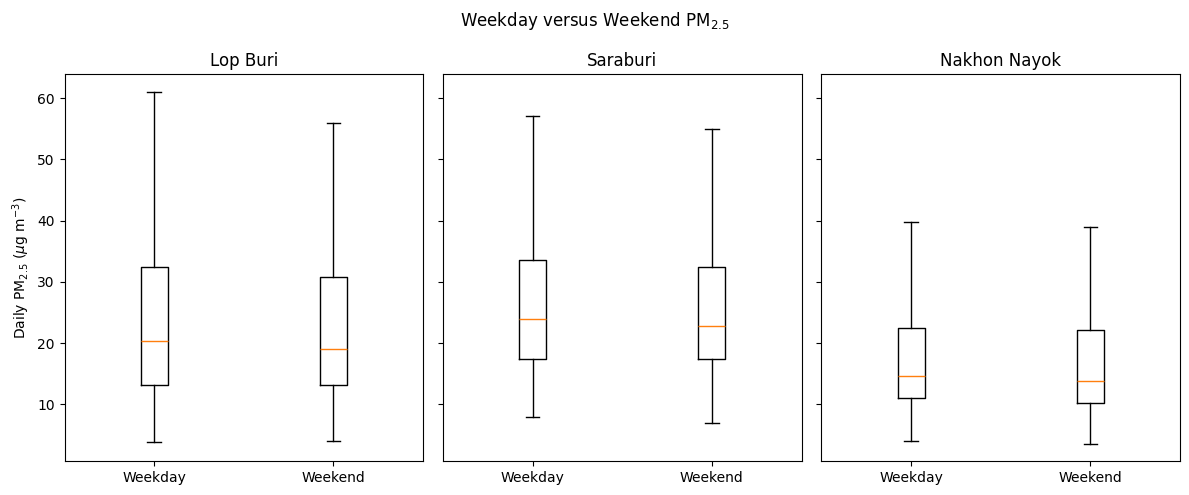


WEEKDAY vs WEEKEND
    province  weekday_n  weekday_median  weekend_n  weekend_median        U      p
    Lop Buri        888           20.30        354          19.100 162063.5 0.3918
    Saraburi       1303           24.00        522          22.875 354610.0 0.1533
Nakhon Nayok        520           14.65        205          13.900  55447.0 0.3980


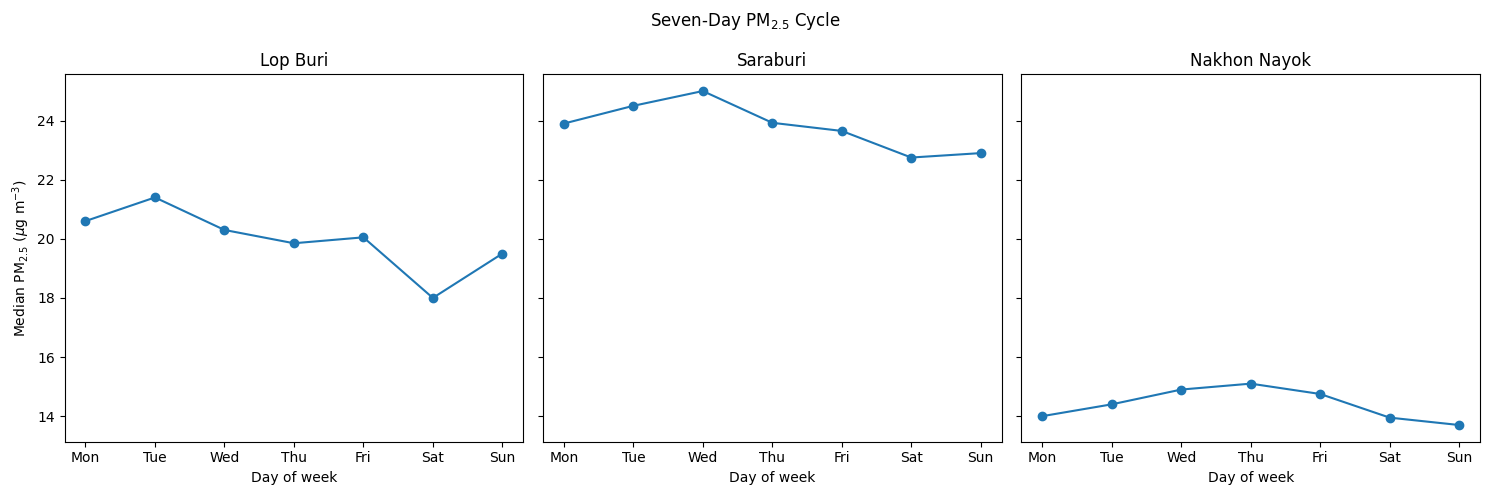


STATION SUMMARY
assigned_province stationID        tier    n  mean    sd  median   q1    q3   iqr  min   max  p05   p95
         Lop Buri      104t surrounding  725 26.79 15.70   23.20 14.5 35.90 21.40  4.7 101.2  8.6 57.16
         Lop Buri      116t surrounding  364 23.00 13.94   19.45 14.0 27.42 13.42  5.3  91.4  7.8 49.75
         Lop Buri       99t      inside 1234 24.62 15.33   20.00 13.2 32.08 18.88  3.9  95.0  8.6 55.43
     Nakhon Nayok      105t      inside  725 17.38  9.27   14.40 10.7 22.40 11.70  3.6  72.6  7.0 34.38
         Saraburi       21t surrounding 1760 21.76 13.85   17.35 11.3 29.00 17.70  4.6  94.0  7.0 50.00
         Saraburi       24t      inside 1762 32.23 15.83   28.25 21.0 40.00 19.00  8.0 119.0 14.0 63.00
         Saraburi       25t      inside 1642 22.21 12.84   18.20 13.3 28.00 14.70  3.0  89.0  8.2 47.00

FINAL INTEGRITY CHECK
Duplicate province-date rows: 0
Missing primary PM2.5: 0
Date range: 2021-01-01 00:00:00 to 2025-12-31 00:00:00
Years: [2021, 20

In [ ]:





# =====================================================================
# CELL 3 — DATE PARSER
# Handles Excel serial dates, Gregorian dates, and Buddhist Era dates.
# =====================================================================
THAI_DIGITS = str.maketrans(
    "๐๑๒๓๔๕๖๗๘๙",
    "0123456789"
)

def _convert_be_years_in_text(x):
    """
    Convert any 4-digit Buddhist Era year (e.g. 2564) in a date string
    to Gregorian year (2021).
    """
    if x is None:
        return x

    s = str(x).strip().translate(THAI_DIGITS)

    if s.lower() in {"", "nan", "nat", "none"}:
        return None

    def repl(match):
        y = int(match.group(0))
        if 2400 <= y <= 2700:
            return str(y - 543)
        return str(y)

    return re.sub(r"\b\d{4}\b", repl, s)


def parse_pcd_dates(series):
    """
    Robustly parse PCD date column.

    Priority:
    1) Excel serial numbers
    2) Text/Timestamp values after Buddhist Era normalization
    3) day-first parsing, with a month-first fallback
    """
    out = pd.Series(
        pd.NaT,
        index=series.index,
        dtype="datetime64[ns]"
    )

    # 1) Excel serial dates
    numeric = pd.to_numeric(series, errors="coerce")
    serial_mask = numeric.between(20000, 60000)

    if serial_mask.any():
        out.loc[serial_mask] = pd.to_datetime(
            numeric.loc[serial_mask],
            unit="D",
            origin="1899-12-30",
            errors="coerce"
        )

    # 2) Remaining values as normalized text
    remaining = out.isna()

    if remaining.any():
        normalized = series.loc[remaining].map(
            _convert_be_years_in_text
        )

        parsed_dayfirst = pd.to_datetime(
            normalized,
            errors="coerce",
            dayfirst=True
        )

        parsed_monthfirst = pd.to_datetime(
            normalized,
            errors="coerce",
            dayfirst=False
        )

        parsed = parsed_dayfirst.fillna(parsed_monthfirst)
        out.loc[remaining] = parsed

    return out


# =====================================================================
# CELL 4 — ROBUST MULTI-YEAR PCD WORKBOOK READERS
#
# Historical Air4Thai workbook layouts are NOT identical:
#   2021-2022 : data sheet "PM2.5", metadata "พารามิเตอร์_สถานี"
#   2023      : data sheet "PM2.5", metadata "รายละเอียดจุดตรวจวัด"
#   2024      : data sheet "Data"
#   2025      : data sheet "DATA"
#
# This reader auto-detects those variants and also searches for the
# actual header row instead of assuming row 1 is always the header.
# =====================================================================

DATA_SHEET_CANDIDATES = [
    "DATA",
    "Data",
    "data",
    "PM2.5",
    "pm2.5",
    "PM25",
    "pm25"
]

META_SHEET_CANDIDATES = [
    "รายละเอียดจุดตรวจวัด",
    "พารามิเตอร์_สถานี",
    "พารามิเตอร์สถานี",
    "station",
    "stations",
    "metadata"
]


def _sheet_norm(x):
    return (
        str(x)
        .strip()
        .lower()
        .replace(" ", "")
        .replace("_", "")
    )


def choose_data_sheet(sheet_names):
    """
    Select the daily PM2.5 data worksheet from historical PCD workbooks.
    Preference:
      DATA/Data -> PM2.5 -> PM25 -> fuzzy match
    """
    norm_map = {
        _sheet_norm(s): s
        for s in sheet_names
    }

    preferred_norm = [
        _sheet_norm(x)
        for x in DATA_SHEET_CANDIDATES
    ]

    for key in preferred_norm:
        if key in norm_map:
            return norm_map[key]

    # Fuzzy fallback
    for s in sheet_names:
        n = _sheet_norm(s)
        if "pm2.5" in n or "pm25" in n:
            return s

    raise ValueError(
        f"Could not identify PM2.5 data sheet. "
        f"Available sheets={sheet_names}"
    )


def choose_meta_sheet(sheet_names):
    """
    Select metadata/station-information worksheet when available.
    """
    norm_map = {
        _sheet_norm(s): s
        for s in sheet_names
    }

    for candidate in META_SHEET_CANDIDATES:
        key = _sheet_norm(candidate)
        if key in norm_map:
            return norm_map[key]

    # Fuzzy fallback
    for s in sheet_names:
        n = _sheet_norm(s)

        if (
            "รายละเอียดจุดตรวจวัด" in str(s)
            or "พารามิเตอร์" in str(s)
            or "station" in n
            or "metadata" in n
        ):
            return s

    return None


def _looks_like_station_code(value):
    """
    Historical PCD station codes commonly look like:
      21T, 24T, 99T, 104T, bkpXX, etc.
    """
    if pd.isna(value):
        return False

    s = str(value).strip()

    patterns = [
        r"^\d{1,4}[A-Za-z]$",
        r"^[A-Za-z]{1,5}\d{1,5}$",
        r"^[A-Za-z]{1,5}\d{1,5}[A-Za-z]?$"
    ]

    return any(
        re.match(p, s)
        for p in patterns
    )


def detect_data_header_row(raw, max_rows=30):
    """
    Detect header row of the daily PM2.5 sheet.

    Scoring considers:
      * Date/วันที่ keywords
      * number of station-code-looking cells
      * number of non-empty cells

    Returns zero-based row number for pandas header=.
    """
    best_row = 0
    best_score = -1

    nrows = min(
        max_rows,
        len(raw)
    )

    for i in range(nrows):
        row = raw.iloc[i]

        strings = [
            str(v).strip()
            for v in row
            if pd.notna(v)
        ]

        joined = " ".join(strings).lower()

        date_keyword = (
            "date" in joined
            or "วันที่" in joined
            or "วัน/เดือน/ปี" in joined
            or "วันเดือนปี" in joined
        )

        station_like = sum(
            _looks_like_station_code(v)
            for v in row
        )

        nonempty = row.notna().sum()

        # Strongly reward rows that contain Date plus many station IDs
        score = (
            (20 if date_keyword else 0)
            + station_like * 3
            + min(nonempty, 20) * 0.2
        )

        if score > best_score:
            best_score = score
            best_row = i

    return best_row


def detect_date_column(df):
    """
    Detect date column by name; otherwise use the first column.
    """
    for c in df.columns:
        n = _sheet_norm(c)

        if (
            "date" in n
            or "วันที่" in str(c)
            or "วันเดือนปี" in str(c)
            or "วัน/เดือน/ปี" in str(c)
        ):
            return c

    return df.columns[0]


def read_pcd_daily(path):
    """
    Read historical PCD Air4Thai DAILY PM2.5 workbook across 2021-2025.

    Output:
      date, stationID, PM25, year, source_file, source_sheet
    """
    xls = pd.ExcelFile(path)

    data_sheet = choose_data_sheet(
        xls.sheet_names
    )

    # First read without a header so we can detect the real header row.
    raw = pd.read_excel(
        path,
        sheet_name=data_sheet,
        header=None
    )

    header_row = detect_data_header_row(
        raw
    )

    d = pd.read_excel(
        path,
        sheet_name=data_sheet,
        header=header_row
    )

    # Remove fully empty columns
    d = d.dropna(
        axis=1,
        how="all"
    )

    if d.shape[1] < 2:
        raise ValueError(
            f"{os.path.basename(path)} / {data_sheet}: "
            "data sheet has fewer than two usable columns."
        )

    date_col = detect_date_column(
        d
    )

    d["_parsed_date"] = parse_pcd_dates(
        d[date_col]
    )

    d = d.dropna(
        subset=["_parsed_date"]
    ).copy()

    # Candidate station columns = all remaining columns.
    # Ignore unnamed/note/helper columns unless they look like station IDs.
    station_cols = []

    for c in d.columns:
        if c in [
            date_col,
            "_parsed_date"
        ]:
            continue

        cs = str(c).strip()

        # Prefer valid station-code names.
        if _looks_like_station_code(cs):
            station_cols.append(c)
            continue

        # Some PCD files may store numeric station IDs as Excel numbers.
        if re.match(
            r"^\d{1,4}\.?0?$",
            cs
        ):
            station_cols.append(c)

    # Fallback: if strict station-code detection fails, use all non-date columns
    # except obviously unnamed columns.
    if len(station_cols) < 2:
        station_cols = [
            c for c in d.columns
            if c not in [
                date_col,
                "_parsed_date"
            ]
            and not str(c).lower().startswith("unnamed")
        ]

    if not station_cols:
        raise ValueError(
            f"{os.path.basename(path)} / {data_sheet}: "
            "no station columns detected."
        )

    long = d.melt(
        id_vars=["_parsed_date"],
        value_vars=station_cols,
        var_name="stationID",
        value_name="PM25"
    )

    long = long.rename(
        columns={
            "_parsed_date": "date"
        }
    )

    # Normalize station IDs
    long["stationID"] = (
        long["stationID"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    long["PM25"] = pd.to_numeric(
        long["PM25"],
        errors="coerce"
    )

    # Negative concentrations are invalid.
    long.loc[
        long["PM25"] < 0,
        "PM25"
    ] = np.nan

    long = long.dropna(
        subset=["PM25"]
    ).copy()

    long["year"] = (
        long["date"]
        .dt.year
    )

    long["source_file"] = (
        os.path.basename(path)
    )

    long["source_sheet"] = (
        data_sheet
    )

    return long


def _find_meta_header(raw, max_rows=30):
    """
    Locate station-metadata header row using Thai/English keywords.
    """
    best = None

    for i in range(
        min(max_rows, len(raw))
    ):
        texts = (
            raw.iloc[i]
            .astype(str)
            .str.strip()
        )

        joined = " | ".join(
            texts.tolist()
        ).lower()

        has_station_code = (
            "รหัสสถานี" in joined
            or "station id" in joined
            or "stationid" in joined
            or "station code" in joined
        )

        if has_station_code:
            best = i
            break

    return best


def _find_column_by_patterns(columns, patterns):
    for c in columns:
        txt = str(c).strip().lower()

        for pattern in patterns:
            if pattern in txt:
                return c

    return None


def read_station_meta(path):
    """
    Read station metadata across historical workbook variants.

    Supports:
      - รายละเอียดจุดตรวจวัด
      - พารามิเตอร์_สถานี

    Returns stationID, siteTH, meta_lat, meta_long when detectable.
    """
    xls = pd.ExcelFile(path)

    meta_sheet = choose_meta_sheet(
        xls.sheet_names
    )

    if meta_sheet is None:
        return pd.DataFrame(
            columns=[
                "stationID",
                "siteTH",
                "meta_lat",
                "meta_long",
                "meta_source_file",
                "meta_source_sheet"
            ]
        )

    raw = pd.read_excel(
        path,
        sheet_name=meta_sheet,
        header=None
    )

    header_row = _find_meta_header(
        raw
    )

    if header_row is None:
        return pd.DataFrame(
            columns=[
                "stationID",
                "siteTH",
                "meta_lat",
                "meta_long",
                "meta_source_file",
                "meta_source_sheet"
            ]
        )

    m = pd.read_excel(
        path,
        sheet_name=meta_sheet,
        header=header_row
    )

    code_col = _find_column_by_patterns(
        m.columns,
        [
            "รหัสสถานี",
            "station id",
            "stationid",
            "station code"
        ]
    )

    name_col = _find_column_by_patterns(
        m.columns,
        [
            "ชื่อสถานี",
            "station name",
            "name"
        ]
    )

    lat_col = _find_column_by_patterns(
        m.columns,
        [
            "latitude",
            "ละติจูด",
            "lat"
        ]
    )

    lon_col = _find_column_by_patterns(
        m.columns,
        [
            "longitude",
            "ลองจิจูด",
            "long",
            "lon"
        ]
    )

    if code_col is None:
        return pd.DataFrame(
            columns=[
                "stationID",
                "siteTH",
                "meta_lat",
                "meta_long",
                "meta_source_file",
                "meta_source_sheet"
            ]
        )

    out = pd.DataFrame()

    out["stationID"] = (
        m[code_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    if name_col is not None:
        out["siteTH"] = (
            m[name_col]
            .astype(str)
            .str.strip()
        )
    else:
        out["siteTH"] = np.nan

    if lat_col is not None:
        out["meta_lat"] = pd.to_numeric(
            m[lat_col],
            errors="coerce"
        )
    else:
        out["meta_lat"] = np.nan

    if lon_col is not None:
        out["meta_long"] = pd.to_numeric(
            m[lon_col],
            errors="coerce"
        )
    else:
        out["meta_long"] = np.nan

    out = out[
        out["stationID"].str.match(
            r"^[a-z0-9]+$",
            na=False
        )
    ].copy()

    out["meta_source_file"] = (
        os.path.basename(path)
    )

    out["meta_source_sheet"] = (
        meta_sheet
    )

    return out.drop_duplicates(
        "stationID"
    )


# =====================================================================
# CELL 5 — READ ALL UPLOADED WORKBOOKS + VERIFY YEARS
# =====================================================================
excel_files = sorted(
    glob.glob(
        os.path.join(
            DATA_DIR,
            "*.xlsx"
        )
    )
    +
    glob.glob(
        os.path.join(
            DATA_DIR,
            "*.xls"
        )
    )
)

excel_files = [
    f for f in excel_files
    if not os.path.basename(f).startswith("~$")
]

if not excel_files:
    raise RuntimeError(
        "No Excel files found in /content."
    )

parts = []
meta_parts = []
file_report = []

print("\nWORKBOOK INSPECTION")
print("=" * 88)

for path in excel_files:
    try:
        p = read_pcd_daily(path)
        m = read_station_meta(path)

        year_counts = (
            p["year"]
            .value_counts()
            .sort_index()
        )

        years_found = sorted(
            p["year"]
            .dropna()
            .unique()
            .tolist()
        )

        file_report.append({
            "file": os.path.basename(path),
            "years_found": ",".join(
                map(str, years_found)
            ),
            "n_station_days": len(p),
            "n_stations": p["stationID"].nunique()
        })

        parts.append(p)
        meta_parts.append(m)

        print(
            f"\n{os.path.basename(path)}"
        )
        print(
            f"  data sheet: {p['source_sheet'].iloc[0] if len(p) else 'unknown'}"
        )
        print(
            f"  years    : {years_found}"
        )
        print(
            f"  stations : {p['stationID'].nunique()}"
        )
        print(
            f"  rows     : {len(p):,}"
        )

        print(
            "  rows/year:"
        )

        for year, count in year_counts.items():
            print(
                f"    {year}: {count:,}"
            )

    except Exception as e:
        print(
            f"\nFAILED: {os.path.basename(path)}"
        )
        print(
            " ",
            repr(e)
        )

if not parts:
    raise RuntimeError(
        "None of the uploaded workbooks could be read."
    )

file_report_df = pd.DataFrame(
    file_report
)

file_report_df.to_csv(
    os.path.join(
        OUT_DIR,
        "01_uploaded_file_report.csv"
    ),
    index=False
)

daily_raw = pd.concat(
    parts,
    ignore_index=True
)

daily_raw = daily_raw[
    daily_raw["year"].isin(
        STUDY_YEARS
    )
].copy()

daily_raw = (
    daily_raw
    .sort_values(
        [
            "stationID",
            "date"
        ]
    )
    .drop_duplicates(
        [
            "stationID",
            "date"
        ],
        keep="first"
    )
    .reset_index(drop=True)
)

if meta_parts:
    station_meta_archive = (
        pd.concat(
            meta_parts,
            ignore_index=True
        )
        .sort_values("stationID")
        .drop_duplicates(
            "stationID",
            keep="first"
        )
    )
else:
    station_meta_archive = pd.DataFrame(
        columns=[
            "stationID",
            "siteTH",
            "meta_lat",
            "meta_long"
        ]
    )

years_present = sorted(
    daily_raw["year"]
    .unique()
    .tolist()
)

missing_years = sorted(
    set(STUDY_YEARS)
    - set(years_present)
)

print("\nCOMBINED ARCHIVE")
print("=" * 88)
print(
    "Date span :",
    daily_raw["date"].min(),
    "to",
    daily_raw["date"].max()
)
print(
    "Years     :",
    years_present
)
print(
    "Stations  :",
    daily_raw["stationID"].nunique()
)
print(
    "Rows      :",
    f"{len(daily_raw):,}"
)

if missing_years:
    print(
        "\n*** IMPORTANT: MISSING YEARS ***"
    )
    print(
        "Missing:",
        missing_years
    )
    print(
        "\nThis means the five-year analysis must NOT continue yet."
    )
    print(
        "Check 01_uploaded_file_report.csv and the workbook inspection above."
    )

    if STRICT_YEAR_CHECK:
        raise RuntimeError(
            f"Missing study years: {missing_years}. "
            "Upload the correct PCD daily PM2.5 workbooks and rerun."
        )

print(
    "\n✅ All requested study years are present."
)


# =====================================================================
# CELL 6 — DOWNLOAD PROVINCE BOUNDARIES
# =====================================================================
PROV_URL = (
    "https://raw.githubusercontent.com/"
    "chingchai/OpenGISData-Thailand/"
    "master/provinces.geojson"
)

PROV_FILE = os.path.join(
    DATA_DIR,
    "th_provinces.geojson"
)

if not os.path.exists(PROV_FILE):
    response = requests.get(
        PROV_URL,
        timeout=120
    )
    response.raise_for_status()

    with open(
        PROV_FILE,
        "wb"
    ) as f:
        f.write(
            response.content
        )

prov = gpd.read_file(
    PROV_FILE
)

if prov.crs is None:
    prov = prov.set_crs(
        epsg=4326
    )

prov = prov.to_crs(
    epsg=4326
)

possible_name_fields = [
    "pro_en",
    "NAME_1",
    "name_en",
    "province_en"
]

name_field = None

for candidate in possible_name_fields:
    if candidate in prov.columns:
        name_field = candidate
        break

if name_field is None:
    raise ValueError(
        "Could not identify English province field. "
        f"Columns={list(prov.columns)}"
    )

prov = prov.rename(
    columns={
        name_field: "boundary_name"
    }
)

prov["boundary_norm"] = (
    prov["boundary_name"]
    .map(_norm)
)

prov["province"] = (
    prov["boundary_norm"]
    .map(TARGET_CANON)
)

target = prov[
    prov["province"].notna()
].copy()

if target["province"].nunique() != 3:
    raise ValueError(
        "Could not match all three target provinces. "
        f"Matched={target[['boundary_name','province']].to_dict('records')}"
    )

print("\nMatched target boundaries:")
print(
    target[
        [
            "boundary_name",
            "province"
        ]
    ].to_string(index=False)
)


# =====================================================================
# CELL 7 — TARGET UNION + BUFFER
# =====================================================================
target_union = (
    target.geometry
    .union_all()
)

target_union_gdf = gpd.GeoDataFrame(
    {
        "name": [
            "target provinces"
        ]
    },
    geometry=[
        target_union
    ],
    crs="EPSG:4326"
)

target_union_m = (
    target_union_gdf
    .to_crs(
        METRIC_CRS
    )
)

buffer_geom_m = (
    target_union_m
    .geometry
    .iloc[0]
    .buffer(
        BUFFER_KM * 1000
    )
)

buffer_gdf_m = gpd.GeoDataFrame(
    {
        "buffer_km": [
            BUFFER_KM
        ]
    },
    geometry=[
        buffer_geom_m
    ],
    crs=METRIC_CRS
)

buffer_gdf = (
    buffer_gdf_m
    .to_crs(
        epsg=4326
    )
)

buffer_geom = (
    buffer_gdf
    .geometry
    .iloc[0]
)


# =====================================================================
# CELL 8 — STATION COORDINATES
# Prefer archive coordinates when present; otherwise use live Air4Thai API.
# =====================================================================
live_station_df = pd.DataFrame(
    columns=[
        "stationID",
        "nameEN",
        "nameTH",
        "areaEN",
        "areaTH",
        "api_lat",
        "api_long"
    ]
)

A4T_URLS = [
    "https://air4thai.pcd.go.th/services/getNewAQI_JSON.php",
    "http://air4thai.pcd.go.th/services/getNewAQI_JSON.php"
]

last_error = None

for url in A4T_URLS:
    try:
        r = requests.get(
            url,
            timeout=120,
            verify=False,
            headers={
                "User-Agent": "Mozilla/5.0"
            }
        )
        r.raise_for_status()
        js = r.json()

        rows = []

        for item in js.get(
            "stations",
            []
        ):
            try:
                lat = float(
                    item.get(
                        "lat",
                        np.nan
                    )
                )

                lon = float(
                    item.get(
                        "long",
                        np.nan
                    )
                )
            except Exception:
                lat = np.nan
                lon = np.nan

            rows.append({
                "stationID": str(
                    item.get(
                        "stationID",
                        ""
                    )
                ).strip().lower(),
                "nameEN": item.get(
                    "nameEN"
                ),
                "nameTH": item.get(
                    "nameTH"
                ),
                "areaEN": item.get(
                    "areaEN"
                ),
                "areaTH": item.get(
                    "areaTH"
                ),
                "api_lat": lat,
                "api_long": lon
            })

        live_station_df = (
            pd.DataFrame(rows)
            .drop_duplicates(
                "stationID"
            )
        )

        print(
            "\nLive Air4Thai station API loaded:",
            url
        )

        break

    except Exception as e:
        last_error = e

if live_station_df.empty:
    print(
        "\nWARNING: Live station API unavailable."
    )
    print(
        "Will use coordinates from the archive workbook if present."
    )
    print(
        "Last API error:",
        last_error
    )

# Merge historical archive station metadata + current API
station_info = (
    station_meta_archive
    .merge(
        live_station_df,
        on="stationID",
        how="outer"
    )
)

# Prefer archive coordinates if available, then API
station_info["lat"] = (
    station_info["meta_lat"]
    .where(
        station_info["meta_lat"].notna(),
        station_info["api_lat"]
    )
)

station_info["long"] = (
    station_info["meta_long"]
    .where(
        station_info["meta_long"].notna(),
        station_info["api_long"]
    )
)

archive_ids = set(
    daily_raw["stationID"]
    .unique()
)

station_info = station_info[
    station_info["stationID"].isin(
        archive_ids
    )
].copy()

missing_coord = station_info[
    station_info["lat"].isna()
    |
    station_info["long"].isna()
].copy()

if len(missing_coord) > 0:
    print(
        "\nArchive stations lacking coordinates:"
    )
    print(
        missing_coord[
            [
                "stationID",
                "siteTH",
                "nameEN"
            ]
        ].to_string(index=False)
    )

station_info_geo = station_info[
    station_info["lat"].notna()
    &
    station_info["long"].notna()
].copy()

stations = gpd.GeoDataFrame(
    station_info_geo,
    geometry=[
        Point(
            lon,
            lat
        )
        for lon, lat in zip(
            station_info_geo["long"],
            station_info_geo["lat"]
        )
    ],
    crs="EPSG:4326"
)

print(
    "\nArchive stations with usable coordinates:",
    len(stations)
)


# =====================================================================
# CELL 9 — SELECT INSIDE + SURROUNDING STATIONS
# =====================================================================
stations["inside_target_union"] = (
    stations.geometry
    .within(
        target_union
    )
)

stations["within_buffer"] = (
    stations.geometry
    .within(
        buffer_geom
    )
)

stations["tier"] = np.select(
    [
        stations[
            "inside_target_union"
        ],
        (
            ~stations[
                "inside_target_union"
            ]
            &
            stations[
                "within_buffer"
            ]
        )
    ],
    [
        "inside",
        "surrounding"
    ],
    default="outside"
)

selected = stations[
    stations["tier"].isin(
        [
            "inside",
            "surrounding"
        ]
    )
].copy()

# Assign containing province, else nearest target province
target_m = target.to_crs(
    METRIC_CRS
)

selected_m = selected.to_crs(
    METRIC_CRS
)

assigned = []
distance_km = []

for _, station in selected_m.iterrows():
    point = station.geometry
    inside_name = None

    for _, province_row in target_m.iterrows():
        if point.within(
            province_row.geometry
        ):
            inside_name = (
                province_row[
                    "province"
                ]
            )
            break

    if inside_name is not None:
        assigned.append(
            inside_name
        )
        distance_km.append(
            0.0
        )
    else:
        distances = (
            target_m.geometry
            .distance(
                point
            )
        )

        nearest_idx = (
            distances.idxmin()
        )

        assigned.append(
            target_m.loc[
                nearest_idx,
                "province"
            ]
        )

        distance_km.append(
            float(
                distances.loc[
                    nearest_idx
                ]
            )
            / 1000.0
        )

selected[
    "assigned_province"
] = assigned

selected[
    "distance_to_target_km"
] = distance_km

selected = (
    selected
    .sort_values(
        [
            "assigned_province",
            "tier",
            "distance_to_target_km",
            "stationID"
        ]
    )
    .reset_index(
        drop=True
    )
)

show_cols = [
    "stationID",
    "siteTH",
    "nameEN",
    "tier",
    "assigned_province",
    "distance_to_target_km",
    "lat",
    "long"
]

show_cols = [
    c for c in show_cols
    if c in selected.columns
]

print("\nSELECTED STATIONS")
print("=" * 100)

print(
    selected[
        show_cols
    ]
    .round(
        {
            "distance_to_target_km": 1,
            "lat": 4,
            "long": 4
        }
    )
    .to_string(
        index=False
    )
)

selected.drop(
    columns="geometry"
).to_csv(
    os.path.join(
        OUT_DIR,
        "02_selected_stations.csv"
    ),
    index=False
)


# =====================================================================
# CELL 10 — BUILD STATION-LEVEL DAILY TABLE
# =====================================================================
daily = daily_raw[
    daily_raw["stationID"].isin(
        selected["stationID"]
    )
].copy()

station_attrs = selected[
    [
        "stationID",
        "tier",
        "assigned_province",
        "distance_to_target_km",
        "lat",
        "long"
    ]
].copy()

for extra_col in [
    "nameEN",
    "siteTH"
]:
    if extra_col in selected.columns:
        station_attrs[
            extra_col
        ] = selected[
            extra_col
        ]

daily = daily.merge(
    station_attrs,
    on="stationID",
    how="left",
    validate="many_to_one"
)

daily["year"] = (
    daily["date"]
    .dt.year
)

daily["month"] = (
    daily["date"]
    .dt.month
)

daily["month_name"] = (
    daily["date"]
    .dt.strftime(
        "%b"
    )
)

daily["dow"] = (
    daily["date"]
    .dt.dayofweek
)

daily["day_name"] = (
    daily["date"]
    .dt.day_name()
)

daily["weekend"] = (
    daily["dow"] >= 5
)

daily["day_type"] = np.where(
    daily["weekend"],
    "Weekend",
    "Weekday"
)

daily["season"] = np.select(
    [
        daily["month"].isin(
            WET_MONTHS
        ),
        daily["month"].isin(
            DRY_MONTHS
        )
    ],
    [
        "Wet",
        "Dry"
    ],
    default="Other"
)

print(
    "\nSelected station-days before monthly QA:",
    f"{len(daily):,}"
)


# =====================================================================
# CELL 11 — MONTH-COMPLETENESS QA (RERUN-SAFE)
# =====================================================================
qa_cols = [
    "year_month",
    "valid_days",
    "days_in_month",
    "completeness",
    "month_pass",
    "valid_days_x",
    "valid_days_y",
    "days_in_month_x",
    "days_in_month_y",
    "completeness_x",
    "completeness_y",
    "month_pass_x",
    "month_pass_y"
]

daily = daily.drop(
    columns=[
        c for c in qa_cols
        if c in daily.columns
    ],
    errors="ignore"
)

daily[
    "year_month"
] = (
    daily["date"]
    .dt.to_period("M")
)

month_count = (
    daily
    .groupby(
        [
            "stationID",
            "year_month"
        ],
        as_index=False
    )["date"]
    .nunique()
    .rename(
        columns={
            "date": "valid_days"
        }
    )
)

month_count[
    "days_in_month"
] = (
    month_count[
        "year_month"
    ]
    .dt.days_in_month
)

month_count[
    "completeness"
] = (
    month_count[
        "valid_days"
    ]
    /
    month_count[
        "days_in_month"
    ]
)

month_count[
    "month_pass"
] = (
    month_count[
        "completeness"
    ]
    >=
    MIN_DAYS_FRAC_MONTH
)

month_count.to_csv(
    os.path.join(
        OUT_DIR,
        "03_station_month_completeness.csv"
    ),
    index=False
)

daily = daily.merge(
    month_count[
        [
            "stationID",
            "year_month",
            "valid_days",
            "days_in_month",
            "completeness",
            "month_pass"
        ]
    ],
    on=[
        "stationID",
        "year_month"
    ],
    how="left",
    validate="many_to_one"
)

before_qc = len(
    daily
)

daily_qc = daily[
    daily["month_pass"]
    .fillna(False)
].copy()

after_qc = len(
    daily_qc
)

print("\nMONTH-COMPLETENESS QA")
print("=" * 80)
print(
    "Station-month PASS:",
    int(
        month_count[
            "month_pass"
        ].sum()
    )
)
print(
    "Station-month FAIL:",
    int(
        (
            ~month_count[
                "month_pass"
            ]
        ).sum()
    )
)
print(
    "Before QA:",
    f"{before_qc:,}"
)
print(
    "After QA :",
    f"{after_qc:,}"
)
print(
    "Retained :",
    f"{100*after_qc/before_qc:.1f}%"
)

failed_months = month_count[
    ~month_count[
        "month_pass"
    ]
].copy()

if len(failed_months) > 0:
    failed_months[
        "completeness_pct"
    ] = (
        100
        *
        failed_months[
            "completeness"
        ]
    )

    print(
        "\nFailed station-months:"
    )

    print(
        failed_months[
            [
                "stationID",
                "year_month",
                "valid_days",
                "days_in_month",
                "completeness_pct"
            ]
        ]
        .round(
            {
                "completeness_pct": 1
            }
        )
        .to_string(
            index=False
        )
    )


# =====================================================================
# CELL 12 — YEARLY STATION COMPLETENESS
# No pivot_table/pivot/unstack.
# =====================================================================
station_year = (
    daily_qc
    .groupby(
        [
            "stationID",
            "assigned_province",
            "tier",
            "year"
        ],
        as_index=False
    )["date"]
    .nunique()
    .rename(
        columns={
            "date": "valid_days"
        }
    )
)

expected_by_year = {
    y: (
        366
        if calendar.isleap(y)
        else 365
    )
    for y in STUDY_YEARS
}

station_year[
    "expected_days"
] = (
    station_year[
        "year"
    ]
    .map(
        expected_by_year
    )
)

station_year[
    "completeness_pct"
] = (
    100.0
    *
    station_year[
        "valid_days"
    ]
    /
    station_year[
        "expected_days"
    ]
)

station_year = (
    station_year
    .sort_values(
        [
            "assigned_province",
            "stationID",
            "year"
        ]
    )
    .reset_index(
        drop=True
    )
)

station_year.to_csv(
    os.path.join(
        OUT_DIR,
        "04_station_year_completeness.csv"
    ),
    index=False
)

print("\nSTATION-YEAR COMPLETENESS")
print("=" * 100)

print(
    station_year
    .round(
        {
            "completeness_pct": 1
        }
    )
    .to_string(
        index=False
    )
)

# Manual wide matrix
coverage_rows = []

for keys, group in station_year.groupby(
    [
        "assigned_province",
        "stationID",
        "tier"
    ],
    sort=True
):
    province_name, station_id, tier = keys

    row = {
        "assigned_province": province_name,
        "stationID": station_id,
        "tier": tier
    }

    for year in STUDY_YEARS:
        vals = group.loc[
            group["year"] == year,
            "completeness_pct"
        ]

        row[str(year)] = (
            float(vals.iloc[0])
            if len(vals) > 0
            else np.nan
        )

    coverage_rows.append(
        row
    )

coverage_matrix = pd.DataFrame(
    coverage_rows
)

coverage_matrix.to_csv(
    os.path.join(
        OUT_DIR,
        "04b_station_year_completeness_matrix.csv"
    ),
    index=False
)

print("\nCOMPLETENESS MATRIX (%)")
print("=" * 100)

print(
    coverage_matrix
    .round(1)
    .to_string(
        index=False
    )
)


# =====================================================================
# CELL 13 — PROVINCE-LEVEL DAILY EXPOSURE
#
# Three exposure definitions:
# 1) PM25_inside   = mean of inside-province monitors only
# 2) PM25_network  = mean of inside + assigned surrounding monitors
# 3) PM25_primary  = inside mean when available; network fallback otherwise
# =====================================================================
network_daily = (
    daily_qc
    .groupby(
        [
            "assigned_province",
            "date"
        ],
        as_index=False
    )
    .agg(
        PM25_network=(
            "PM25",
            "mean"
        ),
        PM25_network_median=(
            "PM25",
            "median"
        ),
        n_network_stations=(
            "stationID",
            "nunique"
        )
    )
    .rename(
        columns={
            "assigned_province": "province"
        }
    )
)

inside_daily = (
    daily_qc[
        daily_qc[
            "tier"
        ] == "inside"
    ]
    .groupby(
        [
            "assigned_province",
            "date"
        ],
        as_index=False
    )
    .agg(
        PM25_inside=(
            "PM25",
            "mean"
        ),
        PM25_inside_median=(
            "PM25",
            "median"
        ),
        n_inside_stations=(
            "stationID",
            "nunique"
        )
    )
    .rename(
        columns={
            "assigned_province": "province"
        }
    )
)

province_daily = network_daily.merge(
    inside_daily,
    on=[
        "province",
        "date"
    ],
    how="left",
    validate="one_to_one"
)

province_daily[
    "PM25_primary"
] = (
    province_daily[
        "PM25_inside"
    ]
    .where(
        province_daily[
            "PM25_inside"
        ].notna(),
        province_daily[
            "PM25_network"
        ]
    )
)

province_daily[
    "exposure_source"
] = np.where(
    province_daily[
        "PM25_inside"
    ].notna(),
    "inside",
    "network_fallback"
)

province_daily[
    "year"
] = (
    province_daily[
        "date"
    ]
    .dt.year
)

province_daily[
    "month"
] = (
    province_daily[
        "date"
    ]
    .dt.month
)

province_daily[
    "month_name"
] = (
    province_daily[
        "date"
    ]
    .dt.strftime(
        "%b"
    )
)

province_daily[
    "dow"
] = (
    province_daily[
        "date"
    ]
    .dt.dayofweek
)

province_daily[
    "day_name"
] = (
    province_daily[
        "date"
    ]
    .dt.day_name()
)

province_daily[
    "weekend"
] = (
    province_daily[
        "dow"
    ] >= 5
)

province_daily[
    "day_type"
] = np.where(
    province_daily[
        "weekend"
    ],
    "Weekend",
    "Weekday"
)

province_daily[
    "season"
] = np.select(
    [
        province_daily[
            "month"
        ].isin(
            WET_MONTHS
        ),
        province_daily[
            "month"
        ].isin(
            DRY_MONTHS
        )
    ],
    [
        "Wet",
        "Dry"
    ],
    default="Other"
)

province_daily = (
    province_daily
    .sort_values(
        [
            "province",
            "date"
        ]
    )
    .reset_index(
        drop=True
    )
)

province_daily.to_csv(
    os.path.join(
        OUT_DIR,
        "05_province_daily_pm25.csv"
    ),
    index=False
)

station_export = (
    daily_qc
    .drop(
        columns=[
            "year_month"
        ],
        errors="ignore"
    )
)

station_export.to_csv(
    os.path.join(
        OUT_DIR,
        "06_station_daily_pm25_QC.csv"
    ),
    index=False
)

print("\nPROVINCE DAILY EXPOSURE")
print("=" * 100)

summary_rows = []

for province, group in province_daily.groupby(
    "province"
):
    summary_rows.append({
        "province": province,
        "first_date": group["date"].min(),
        "last_date": group["date"].max(),
        "days": group["date"].nunique(),
        "mean_primary": group["PM25_primary"].mean(),
        "median_primary": group["PM25_primary"].median(),
        "inside_days": (
            group["exposure_source"]
            == "inside"
        ).sum(),
        "fallback_days": (
            group["exposure_source"]
            == "network_fallback"
        ).sum(),
        "mean_n_network": group["n_network_stations"].mean()
    })

province_summary = pd.DataFrame(
    summary_rows
)

print(
    province_summary
    .round(2)
    .to_string(
        index=False
    )
)

province_summary.to_csv(
    os.path.join(
        OUT_DIR,
        "06b_province_exposure_summary.csv"
    ),
    index=False
)


# =====================================================================
# CELL 14 — DESCRIPTIVE STATISTICS HELPER
# =====================================================================
def describe_values(values):
    s = pd.Series(
        values
    ).dropna()

    if len(s) == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "sd": np.nan,
            "median": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "iqr": np.nan,
            "min": np.nan,
            "max": np.nan,
            "p05": np.nan,
            "p95": np.nan
        }

    q1 = s.quantile(
        0.25
    )

    q3 = s.quantile(
        0.75
    )

    return {
        "n": len(s),
        "mean": s.mean(),
        "sd": s.std(),
        "median": s.median(),
        "q1": q1,
        "q3": q3,
        "iqr": q3 - q1,
        "min": s.min(),
        "max": s.max(),
        "p05": s.quantile(0.05),
        "p95": s.quantile(0.95)
    }


def make_stats(
    df,
    group_cols,
    value_col="PM25_primary"
):
    rows = []

    for keys, group in df.groupby(
        group_cols,
        sort=True
    ):
        if not isinstance(
            keys,
            tuple
        ):
            keys = (
                keys,
            )

        row = dict(
            zip(
                group_cols,
                keys
            )
        )

        row.update(
            describe_values(
                group[
                    value_col
                ]
            )
        )

        rows.append(
            row
        )

    return pd.DataFrame(
        rows
    )


# =====================================================================
# CELL 15 — FIGURE 1: STUDY AREA + STATIONS
# =====================================================================
station_mean = (
    daily_qc
    .groupby(
        "stationID",
        as_index=False
    )
    .agg(
        PM25_mean=(
            "PM25",
            "mean"
        )
    )
)

sel_map = selected.merge(
    station_mean,
    on="stationID",
    how="left",
    validate="one_to_one"
)

minx, miny, maxx, maxy = (
    buffer_gdf
    .total_bounds
)

fig, ax = plt.subplots(
    figsize=(9, 8)
)

prov.boundary.plot(
    ax=ax,
    linewidth=0.5
)

target.boundary.plot(
    ax=ax,
    linewidth=1.4
)

buffer_gdf.boundary.plot(
    ax=ax,
    linewidth=1.0,
    linestyle="--"
)

scatter_for_colorbar = None

for tier, marker in [
    (
        "inside",
        "o"
    ),
    (
        "surrounding",
        "^"
    )
]:
    sub = sel_map[
        sel_map[
            "tier"
        ] == tier
    ]

    if sub.empty:
        continue

    scatter_for_colorbar = ax.scatter(
        sub["long"],
        sub["lat"],
        c=sub["PM25_mean"],
        marker=marker,
        s=85,
        label=tier.capitalize()
    )

for _, row in sel_map.iterrows():
    ax.annotate(
        row[
            "stationID"
        ].upper(),
        (
            row["long"],
            row["lat"]
        ),
        xytext=(
            4,
            4
        ),
        textcoords="offset points",
        fontsize=8
    )

for _, row in target.iterrows():
    rp = (
        row.geometry
        .representative_point()
    )

    ax.annotate(
        row[
            "province"
        ],
        (
            rp.x,
            rp.y
        ),
        ha="center",
        fontsize=9
    )

if scatter_for_colorbar is not None:
    cbar = fig.colorbar(
        scatter_for_colorbar,
        ax=ax,
        shrink=0.8
    )

    cbar.set_label(
        "Mean PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
    )

ax.set_xlim(
    minx - 0.15,
    maxx + 0.15
)

ax.set_ylim(
    miny - 0.15,
    maxy + 0.15
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    f"PM$_{{2.5}}$ Monitoring Network\n"
    f"Inside and surrounding stations within {BUFFER_KM} km"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig01_station_map.png"
    ),
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# =====================================================================
# CELL 16 — DAILY TIME SERIES
# =====================================================================
fig, axes = plt.subplots(
    len(
        TARGET_PROVINCES
    ),
    1,
    figsize=(12, 9),
    sharex=True
)

if len(
    TARGET_PROVINCES
) == 1:
    axes = [
        axes
    ]

for ax, province in zip(
    axes,
    TARGET_PROVINCES
):
    sub = province_daily[
        province_daily[
            "province"
        ] == province
    ].sort_values(
        "date"
    )

    if sub.empty:
        ax.set_title(
            f"{province}: no data"
        )
        continue

    ax.plot(
        sub["date"],
        sub["PM25_primary"],
        linewidth=0.65,
        label="Daily primary exposure"
    )

    rolling = (
        sub[
            [
                "date",
                "PM25_primary"
            ]
        ]
        .set_index(
            "date"
        )[
            "PM25_primary"
        ]
        .rolling(
            "30D",
            min_periods=10
        )
        .mean()
    )

    ax.plot(
        rolling.index,
        rolling.values,
        linewidth=1.5,
        label="30-day rolling mean"
    )

    ax.set_title(
        province
    )

    ax.set_ylabel(
        "PM$_{2.5}$\n($\\mu$g m$^{-3}$)"
    )

    ax.legend(
        fontsize=8
    )

axes[
    -1
].set_xlabel(
    "Date"
)

fig.suptitle(
    "Daily PM$_{2.5}$ Exposure, 2021-2025",
    y=0.995
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig02_daily_timeseries.png"
    ),
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# =====================================================================
# CELL 17 — INTERANNUAL VARIATION
# =====================================================================
annual_stats = make_stats(
    province_daily,
    [
        "province",
        "year"
    ]
)

annual_stats.to_csv(
    os.path.join(
        OUT_DIR,
        "07_annual_statistics.csv"
    ),
    index=False
)

print("\nANNUAL STATISTICS")
print("=" * 110)

print(
    annual_stats
    .round(2)
    .to_string(
        index=False
    )
)

annual_tests = []

fig, axes = plt.subplots(
    1,
    len(
        TARGET_PROVINCES
    ),
    figsize=(15, 5),
    sharey=True
)

if len(
    TARGET_PROVINCES
) == 1:
    axes = [
        axes
    ]

for ax, province in zip(
    axes,
    TARGET_PROVINCES
):
    sub = province_daily[
        province_daily[
            "province"
        ] == province
    ]

    groups = []
    positions = []
    labels = []

    for pos, year in enumerate(
        STUDY_YEARS,
        start=1
    ):
        arr = sub.loc[
            sub[
                "year"
            ] == year,
            "PM25_primary"
        ].dropna().to_numpy()

        if len(arr) > 0:
            groups.append(
                arr
            )
            positions.append(
                pos
            )
            labels.append(
                str(
                    year
                )
            )

    if groups:
        ax.boxplot(
            groups,
            positions=positions,
            showfliers=False
        )

        ax.plot(
            positions,
            [
                np.median(
                    g
                )
                for g in groups
            ],
            marker="o",
            linewidth=1.2
        )

    ax.set_xticks(
        positions
    )

    ax.set_xticklabels(
        labels,
        rotation=45
    )

    ax.set_title(
        province
    )

    if len(groups) >= 2:
        result = kruskal(
            *groups
        )

        annual_tests.append({
            "province": province,
            "H": result.statistic,
            "p": result.pvalue
        })

axes[
    0
].set_ylabel(
    "Daily PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

fig.suptitle(
    "Interannual Variation of Daily PM$_{2.5}$"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig03_interannual_boxplots.png"
    ),
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

pd.DataFrame(
    annual_tests
).to_csv(
    os.path.join(
        OUT_DIR,
        "08_annual_Kruskal_Wallis.csv"
    ),
    index=False
)


# =====================================================================
# CELL 18 — MONTHLY CLIMATOLOGY
# =====================================================================
monthly_stats = make_stats(
    province_daily,
    [
        "province",
        "month"
    ]
)

monthly_stats.to_csv(
    os.path.join(
        OUT_DIR,
        "09_monthly_statistics.csv"
    ),
    index=False
)

month_labels = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec"
]

monthly_tests = []

fig, axes = plt.subplots(
    len(
        TARGET_PROVINCES
    ),
    1,
    figsize=(11, 10),
    sharex=True,
    sharey=True
)

if len(
    TARGET_PROVINCES
) == 1:
    axes = [
        axes
    ]

for ax, province in zip(
    axes,
    TARGET_PROVINCES
):
    sub = province_daily[
        province_daily[
            "province"
        ] == province
    ]

    groups = []
    positions = []

    for month in range(
        1,
        13
    ):
        arr = sub.loc[
            sub[
                "month"
            ] == month,
            "PM25_primary"
        ].dropna().to_numpy()

        if len(arr) > 0:
            groups.append(
                arr
            )
            positions.append(
                month
            )

    if groups:
        ax.boxplot(
            groups,
            positions=positions,
            showfliers=False
        )

        ax.plot(
            positions,
            [
                np.median(
                    g
                )
                for g in groups
            ],
            marker="o",
            linewidth=1.2
        )

    ax.set_title(
        province
    )

    ax.set_ylabel(
        "PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
    )

    if len(groups) >= 2:
        result = kruskal(
            *groups
        )

        monthly_tests.append({
            "province": province,
            "H": result.statistic,
            "p": result.pvalue
        })

axes[
    -1
].set_xticks(
    range(
        1,
        13
    )
)

axes[
    -1
].set_xticklabels(
    month_labels
)

axes[
    -1
].set_xlabel(
    "Month"
)

fig.suptitle(
    "Monthly Climatology of Daily PM$_{2.5}$",
    y=0.995
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig04_monthly_boxplots.png"
    ),
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

pd.DataFrame(
    monthly_tests
).to_csv(
    os.path.join(
        OUT_DIR,
        "10_monthly_Kruskal_Wallis.csv"
    ),
    index=False
)


# =====================================================================
# CELL 19 — YEAR x MONTH HEATMAP
# No pivot_table.
# =====================================================================
for province in TARGET_PROVINCES:
    sub = province_daily[
        province_daily[
            "province"
        ] == province
    ]

    matrix = np.full(
        (
            len(
                STUDY_YEARS
            ),
            12
        ),
        np.nan
    )

    for i, year in enumerate(
        STUDY_YEARS
    ):
        for j, month in enumerate(
            range(
                1,
                13
            )
        ):
            values = sub.loc[
                (
                    sub[
                        "year"
                    ] == year
                )
                &
                (
                    sub[
                        "month"
                    ] == month
                ),
                "PM25_primary"
            ].dropna()

            if len(values) > 0:
                matrix[
                    i,
                    j
                ] = values.mean()

    fig, ax = plt.subplots(
        figsize=(10, 4.8)
    )

    im = ax.imshow(
        matrix,
        aspect="auto"
    )

    ax.set_xticks(
        np.arange(
            12
        )
    )

    ax.set_xticklabels(
        month_labels
    )

    ax.set_yticks(
        np.arange(
            len(
                STUDY_YEARS
            )
        )
    )

    ax.set_yticklabels(
        STUDY_YEARS
    )

    ax.set_xlabel(
        "Month"
    )

    ax.set_ylabel(
        "Year"
    )

    ax.set_title(
        f"{province}: Monthly Mean PM$_{{2.5}}$"
    )

    cbar = fig.colorbar(
        im,
        ax=ax
    )

    cbar.set_label(
        "PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
    )

    for i in range(
        matrix.shape[
            0
        ]
    ):
        for j in range(
            matrix.shape[
                1
            ]
        ):
            value = matrix[
                i,
                j
            ]

            if np.isfinite(
                value
            ):
                ax.text(
                    j,
                    i,
                    f"{value:.1f}",
                    ha="center",
                    va="center",
                    fontsize=7
                )

    plt.tight_layout()

    safe_name = province.replace(
        " ",
        "_"
    )

    plt.savefig(
        os.path.join(
            OUT_DIR,
            f"Fig05_heatmap_{safe_name}.png"
        ),
        dpi=FIG_DPI,
        bbox_inches="tight"
    )

    plt.show()


# =====================================================================
# CELL 20 — DRY vs WET SEASON
# =====================================================================
season_stats = make_stats(
    province_daily[
        province_daily[
            "season"
        ].isin(
            [
                "Dry",
                "Wet"
            ]
        )
    ],
    [
        "province",
        "season"
    ]
)

season_stats.to_csv(
    os.path.join(
        OUT_DIR,
        "11_season_statistics.csv"
    ),
    index=False
)

season_tests = []

fig, axes = plt.subplots(
    1,
    len(
        TARGET_PROVINCES
    ),
    figsize=(12, 5),
    sharey=True
)

if len(
    TARGET_PROVINCES
) == 1:
    axes = [
        axes
    ]

for ax, province in zip(
    axes,
    TARGET_PROVINCES
):
    sub = province_daily[
        province_daily[
            "province"
        ] == province
    ]

    dry = sub.loc[
        sub[
            "season"
        ] == "Dry",
        "PM25_primary"
    ].dropna()

    wet = sub.loc[
        sub[
            "season"
        ] == "Wet",
        "PM25_primary"
    ].dropna()

    if (
        len(
            dry
        ) > 0
        and
        len(
            wet
        ) > 0
    ):
        result = mannwhitneyu(
            dry,
            wet,
            alternative="two-sided"
        )

        season_tests.append({
            "province": province,
            "dry_n": len(dry),
            "dry_median": dry.median(),
            "wet_n": len(wet),
            "wet_median": wet.median(),
            "U": result.statistic,
            "p": result.pvalue
        })

        ax.boxplot(
            [
                dry.to_numpy(),
                wet.to_numpy()
            ],
            labels=[
                "Dry\nNov-Apr",
                "Wet\nMay-Oct"
            ],
            showfliers=False
        )

    ax.set_title(
        province
    )

axes[
    0
].set_ylabel(
    "Daily PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

fig.suptitle(
    "Dry versus Wet Season PM$_{2.5}$"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig06_dry_wet.png"
    ),
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

season_tests_df = pd.DataFrame(
    season_tests
)

season_tests_df.to_csv(
    os.path.join(
        OUT_DIR,
        "12_season_Mann_Whitney.csv"
    ),
    index=False
)

print("\nDRY vs WET")
print("=" * 90)

print(
    season_tests_df
    .round(4)
    .to_string(
        index=False
    )
)


# =====================================================================
# CELL 21 — WEEKDAY vs WEEKEND
# =====================================================================
daytype_stats = make_stats(
    province_daily,
    [
        "province",
        "day_type"
    ]
)

daytype_stats.to_csv(
    os.path.join(
        OUT_DIR,
        "13_weekday_weekend_statistics.csv"
    ),
    index=False
)

week_tests = []

fig, axes = plt.subplots(
    1,
    len(
        TARGET_PROVINCES
    ),
    figsize=(12, 5),
    sharey=True
)

if len(
    TARGET_PROVINCES
) == 1:
    axes = [
        axes
    ]

for ax, province in zip(
    axes,
    TARGET_PROVINCES
):
    sub = province_daily[
        province_daily[
            "province"
        ] == province
    ]

    weekday = sub.loc[
        sub[
            "day_type"
        ] == "Weekday",
        "PM25_primary"
    ].dropna()

    weekend = sub.loc[
        sub[
            "day_type"
        ] == "Weekend",
        "PM25_primary"
    ].dropna()

    if (
        len(
            weekday
        ) > 0
        and
        len(
            weekend
        ) > 0
    ):
        result = mannwhitneyu(
            weekday,
            weekend,
            alternative="two-sided"
        )

        week_tests.append({
            "province": province,
            "weekday_n": len(weekday),
            "weekday_median": weekday.median(),
            "weekend_n": len(weekend),
            "weekend_median": weekend.median(),
            "U": result.statistic,
            "p": result.pvalue
        })

        ax.boxplot(
            [
                weekday.to_numpy(),
                weekend.to_numpy()
            ],
            labels=[
                "Weekday",
                "Weekend"
            ],
            showfliers=False
        )

    ax.set_title(
        province
    )

axes[
    0
].set_ylabel(
    "Daily PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

fig.suptitle(
    "Weekday versus Weekend PM$_{2.5}$"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig07_weekday_weekend.png"
    ),
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

week_tests_df = pd.DataFrame(
    week_tests
)

week_tests_df.to_csv(
    os.path.join(
        OUT_DIR,
        "14_weekday_weekend_Mann_Whitney.csv"
    ),
    index=False
)

print("\nWEEKDAY vs WEEKEND")
print("=" * 90)

print(
    week_tests_df
    .round(4)
    .to_string(
        index=False
    )
)


# =====================================================================
# CELL 22 — SEVEN-DAY CYCLE
# =====================================================================
DOW_ORDER = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_stats = make_stats(
    province_daily,
    [
        "province",
        "day_name"
    ]
)

weekly_stats.to_csv(
    os.path.join(
        OUT_DIR,
        "15_seven_day_statistics.csv"
    ),
    index=False
)

fig, axes = plt.subplots(
    1,
    len(
        TARGET_PROVINCES
    ),
    figsize=(15, 5),
    sharey=True
)

if len(
    TARGET_PROVINCES
) == 1:
    axes = [
        axes
    ]

for ax, province in zip(
    axes,
    TARGET_PROVINCES
):
    sub = province_daily[
        province_daily[
            "province"
        ] == province
    ]

    medians = []

    for day_name in DOW_ORDER:
        values = sub.loc[
            sub[
                "day_name"
            ] == day_name,
            "PM25_primary"
        ].dropna()

        medians.append(
            values.median()
            if len(values) > 0
            else np.nan
        )

    ax.plot(
        range(
            7
        ),
        medians,
        marker="o",
        linewidth=1.5
    )

    ax.set_xticks(
        range(
            7
        )
    )

    ax.set_xticklabels(
        [
            "Mon",
            "Tue",
            "Wed",
            "Thu",
            "Fri",
            "Sat",
            "Sun"
        ]
    )

    ax.set_title(
        province
    )

    ax.set_xlabel(
        "Day of week"
    )

axes[
    0
].set_ylabel(
    "Median PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

fig.suptitle(
    "Seven-Day PM$_{2.5}$ Cycle"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUT_DIR,
        "Fig08_seven_day_cycle.png"
    ),
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# =====================================================================
# CELL 23 — PER-STATION SUMMARY
# =====================================================================
station_summary = make_stats(
    daily_qc,
    [
        "assigned_province",
        "stationID",
        "tier"
    ],
    value_col="PM25"
)

station_summary.to_csv(
    os.path.join(
        OUT_DIR,
        "16_station_summary.csv"
    ),
    index=False
)

print("\nSTATION SUMMARY")
print("=" * 110)

print(
    station_summary
    .round(2)
    .to_string(
        index=False
    )
)


# =====================================================================
# CELL 24 — MORTALITY-LINKAGE MASTER FILE + FINAL CHECK
# =====================================================================
mortality_cols = [
    "date",
    "province",
    "PM25_primary",
    "PM25_inside",
    "PM25_network",
    "PM25_network_median",
    "n_inside_stations",
    "n_network_stations",
    "exposure_source",
    "year",
    "month",
    "month_name",
    "dow",
    "day_name",
    "day_type",
    "season"
]

mortality_ready = province_daily[
    [
        c
        for c in mortality_cols
        if c in province_daily.columns
    ]
].copy()

mortality_ready = (
    mortality_ready
    .sort_values(
        [
            "province",
            "date"
        ]
    )
    .reset_index(
        drop=True
    )
)

master_file = os.path.join(
    OUT_DIR,
    "17_PM25_master_daily_for_mortality_linkage.csv"
)

mortality_ready.to_csv(
    master_file,
    index=False
)

print("\nFINAL INTEGRITY CHECK")
print("=" * 100)

print(
    "Duplicate province-date rows:",
    mortality_ready.duplicated(
        [
            "province",
            "date"
        ]
    ).sum()
)

print(
    "Missing primary PM2.5:",
    mortality_ready[
        "PM25_primary"
    ].isna().sum()
)

print(
    "Date range:",
    mortality_ready[
        "date"
    ].min(),
    "to",
    mortality_ready[
        "date"
    ].max()
)

print(
    "Years:",
    sorted(
        mortality_ready[
            "year"
        ]
        .dropna()
        .unique()
        .tolist()
    )
)

# Manual province-year count table
count_rows = []

for province in TARGET_PROVINCES:
    sub = mortality_ready[
        mortality_ready[
            "province"
        ] == province
    ]

    row = {
        "province": province
    }

    for year in STUDY_YEARS:
        row[
            str(
                year
            )
        ] = int(
            (
                sub[
                    "year"
                ] == year
            ).sum()
        )

    count_rows.append(
        row
    )

province_year_counts = pd.DataFrame(
    count_rows
)

print(
    "\nProvince-year daily record counts:"
)

print(
    province_year_counts
    .to_string(
        index=False
    )
)

province_year_counts.to_csv(
    os.path.join(
        OUT_DIR,
        "17b_province_year_record_counts.csv"
    ),
    index=False
)

print("\n" + "=" * 100)
print("ANALYSIS COMPLETE")
print("=" * 100)
print("Output directory:")
print(OUT_DIR)
print("\nMortality-ready master file:")
print(master_file)


MONTHLY MEANS BY YEAR
    province  year  month  n_days  mean_pm25  median_pm25  sd_daily
    Lop Buri  2022      7      24      11.54        11.00      5.22
    Lop Buri  2022      8      25      12.36        11.00      5.59
    Lop Buri  2022      9      24      11.21        10.50      4.65
    Lop Buri  2022     10      25      21.52        22.00      9.84
    Lop Buri  2022     11      24      17.08        17.50      6.23
    Lop Buri  2022     12      25      25.92        27.00      8.68
    Lop Buri  2023      1      31      34.73        33.00     17.44
    Lop Buri  2023      2      28      33.63        32.50     16.36
    Lop Buri  2023      3      31      34.50        36.00     15.18
    Lop Buri  2023      4      30      41.10        43.00     21.07
    Lop Buri  2023      5      31      25.64        26.30      9.67
    Lop Buri  2023      6      30      18.54        13.55     13.73
    Lop Buri  2023      7      30      18.67        13.65     13.73
    Lop Buri  2023      8

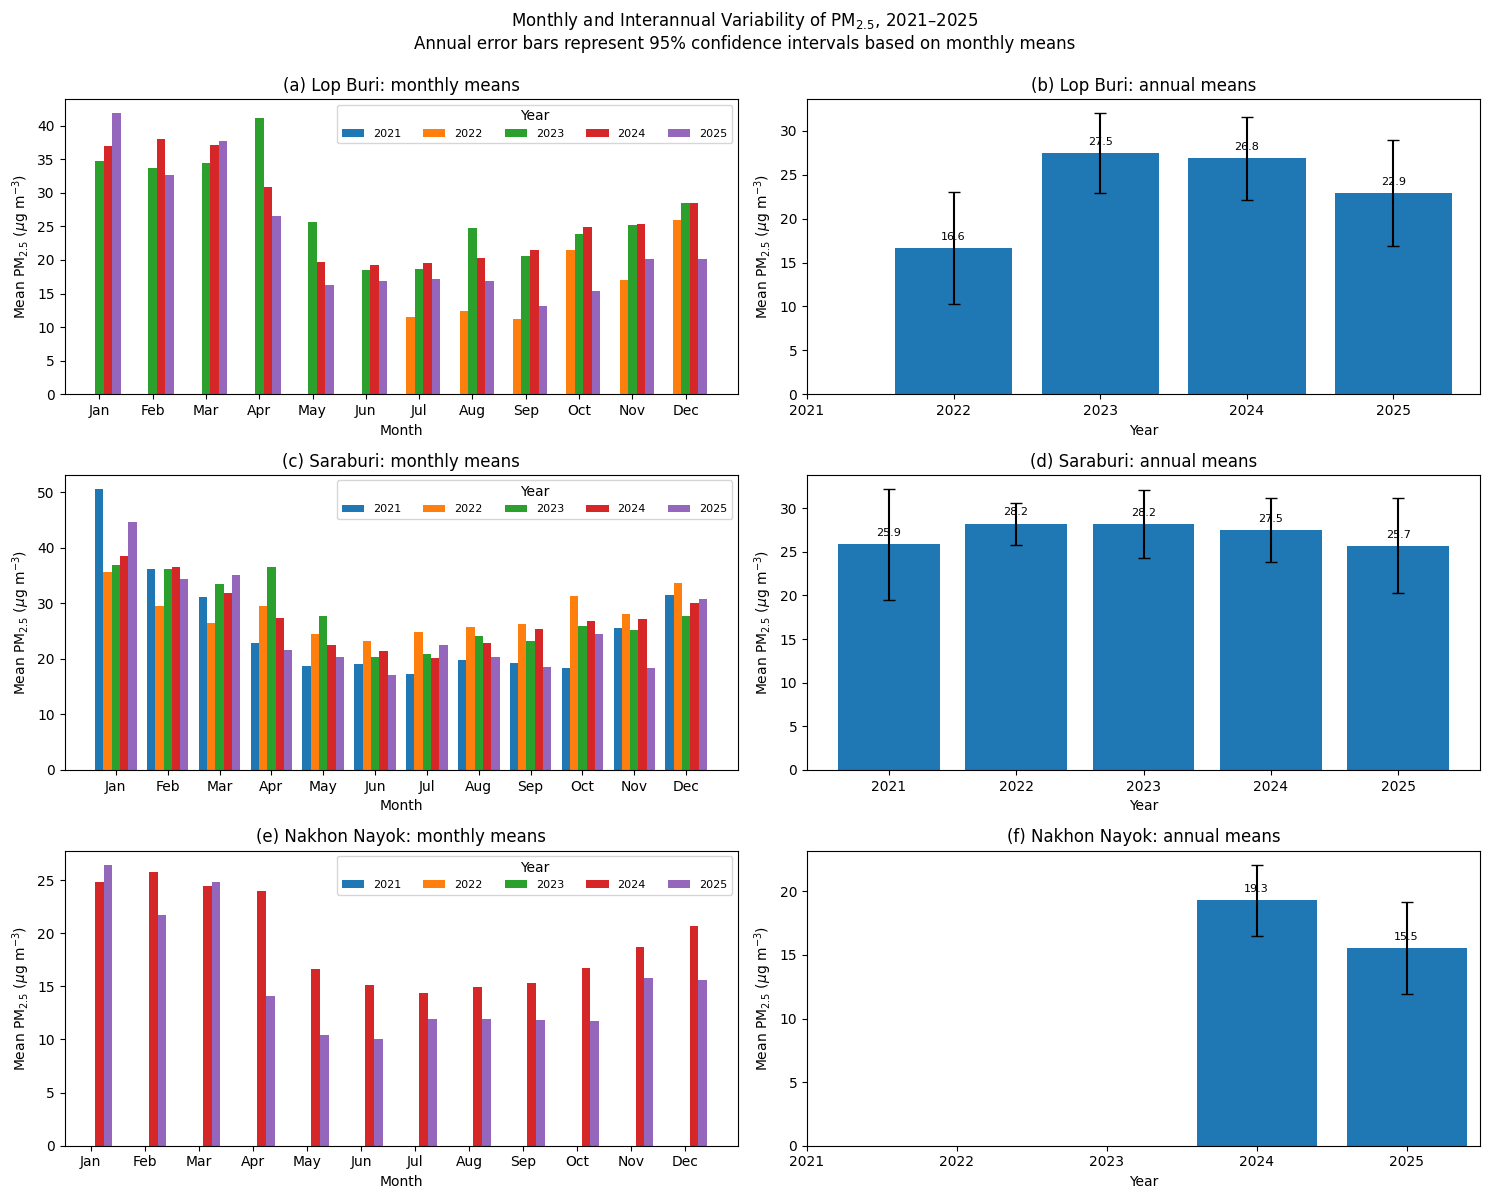

Saved: /content/pm25_outputs/Fig09_monthly_and_annual_PM25.png
✅ Cell 26 completed successfully.

ANNUAL THEIL–SEN RESULTS
    province  n_years  sen_slope_ug_m3_per_year  sen_intercept  sen_slope_ci95_low  sen_slope_ci95_high  kendall_tau  kendall_p
    Lop Buri        4                    0.7363     -1465.1333             -3.9513              10.8589          0.0     1.0000
    Saraburi        5                   -0.2045       441.1936             -1.8486               2.3666         -0.4     0.4833
Nakhon Nayok        2                       NaN            NaN                 NaN                  NaN          NaN        NaN

Interpretation note: annual Sen's slope is based on only five yearly means and should be reported as a descriptive 2021–2025 temporal tendency.

✅ Cell 27 completed successfully.

SEASONAL MANN–KENDALL + SEASONAL SEN'S SLOPE
    province  n_monthly_observations  seasonal_S  seasonal_var_S  seasonal_Z  seasonal_tau  seasonal_MK_p  seasonal_sen_slope_ug_m3_per_yea

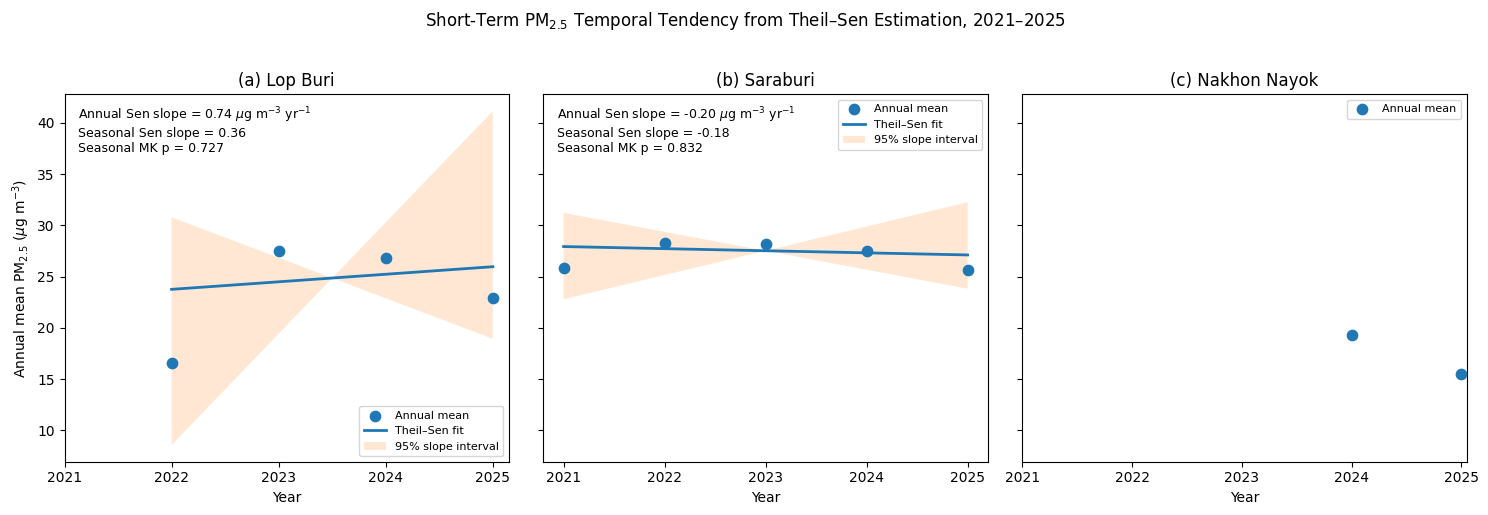

Saved: /content/pm25_outputs/Fig10_annual_Theil_Sen_trend.png
✅ Cell 29 completed successfully.

TREND SENSITIVITY: PRIMARY vs NETWORK EXPOSURE
    province exposure_definition  n_monthly_observations  seasonal_tau  seasonal_MK_p  seasonal_sen_slope_ug_m3_per_year  seasonal_sen_ci95_low  seasonal_sen_ci95_high                   direction
    Lop Buri        PM25_primary                      42        0.0741         0.7273                             0.3617                -2.4367                  1.0871 Increasing, not significant
    Saraburi        PM25_primary                      60       -0.0333         0.8320                            -0.1779                -0.5129                  0.7371 Decreasing, not significant
Nakhon Nayok        PM25_primary                      24       -0.6667         0.0433                            -3.7520                -5.0642                 -2.6722                  Decreasing
    Lop Buri        PM25_network                      42        0.0370  

In [ ]:
# =====================================================================
# CELL 25 — PREPARE MONTHLY AND ANNUAL PM2.5 SUMMARIES
# Run after Cell 24 of the complete PM2.5 workflow.
#
# Main exposure variable:
#   PM25_primary = inside-province mean when available;
#                  network fallback otherwise.
# =====================================================================

from scipy.stats import t, theilslopes, kendalltau, norm

TREND_VALUE_COL = "PM25_primary"

required_cols = [
    "date",
    "province",
    "year",
    "month",
    TREND_VALUE_COL
]

missing_cols = [
    c for c in required_cols
    if c not in province_daily.columns
]

if missing_cols:
    raise RuntimeError(
        "province_daily is missing required columns: "
        + ", ".join(missing_cols)
    )

# Keep only requested study years and non-missing PM2.5
trend_daily = province_daily[
    province_daily["year"].isin(STUDY_YEARS)
].dropna(
    subset=[TREND_VALUE_COL]
).copy()

# ---------------------------------------------------------------------
# 25.1 Monthly means for each province × year × month
# ---------------------------------------------------------------------
monthly_year_rows = []

for keys, g in trend_daily.groupby(
    ["province", "year", "month"],
    sort=True
):
    province, year, month = keys
    s = g[TREND_VALUE_COL].dropna()

    monthly_year_rows.append({
        "province": province,
        "year": int(year),
        "month": int(month),
        "n_days": int(len(s)),
        "mean_pm25": s.mean(),
        "median_pm25": s.median(),
        "sd_daily": s.std()
    })

monthly_year = pd.DataFrame(
    monthly_year_rows
).sort_values(
    ["province", "year", "month"]
).reset_index(drop=True)

# ---------------------------------------------------------------------
# 25.2 Annual means
#
# For the annual uncertainty shown in Figure 9b, use the 12 monthly means
# as the sampling units rather than all daily observations.
# This avoids an unrealistically narrow CI caused by treating strongly
# autocorrelated daily values as independent.
# ---------------------------------------------------------------------
annual_year_rows = []

for keys, g in monthly_year.groupby(
    ["province", "year"],
    sort=True
):
    province, year = keys
    s = g["mean_pm25"].dropna()
    n_months = len(s)

    mean_pm25 = s.mean()
    median_monthly = s.median()
    sd_monthly = s.std(ddof=1) if n_months > 1 else np.nan

    if n_months > 1 and np.isfinite(sd_monthly):
        sem = sd_monthly / np.sqrt(n_months)
        crit = t.ppf(0.975, df=n_months - 1)
        ci_low = mean_pm25 - crit * sem
        ci_high = mean_pm25 + crit * sem
    else:
        sem = np.nan
        ci_low = np.nan
        ci_high = np.nan

    annual_year_rows.append({
        "province": province,
        "year": int(year),
        "n_months": int(n_months),
        "annual_mean_pm25": mean_pm25,
        "annual_median_monthly_pm25": median_monthly,
        "sd_monthly_means": sd_monthly,
        "se_monthly_means": sem,
        "ci95_low": ci_low,
        "ci95_high": ci_high
    })

annual_year = pd.DataFrame(
    annual_year_rows
).sort_values(
    ["province", "year"]
).reset_index(drop=True)

# Save
monthly_year.to_csv(
    os.path.join(
        OUT_DIR,
        "18_monthly_mean_by_year.csv"
    ),
    index=False
)

annual_year.to_csv(
    os.path.join(
        OUT_DIR,
        "19_annual_mean_with_monthly_CI.csv"
    ),
    index=False
)

print("\nMONTHLY MEANS BY YEAR")
print("=" * 100)
print(
    monthly_year
    .round(2)
    .to_string(index=False)
)

print("\nANNUAL MEANS")
print("=" * 100)
print(
    annual_year
    .round(2)
    .to_string(index=False)
)

print("\n✅ Cell 25 completed successfully.")


# ================================================================================
# COPY AS CELL 26
# ================================================================================
# =====================================================================
# CELL 26 — FIGURE 9
# LEFT : monthly mean PM2.5 for each of the five years
# RIGHT: annual mean PM2.5 with 95% CI based on monthly means
#
# Layout:
#   Row 1 = Lop Buri
#   Row 2 = Saraburi
#   Row 3 = Nakhon Nayok
# =====================================================================

month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

years_plot = STUDY_YEARS
x_month = np.arange(1, 13)

fig, axes = plt.subplots(
    len(TARGET_PROVINCES),
    2,
    figsize=(15, 12)
)

if len(TARGET_PROVINCES) == 1:
    axes = np.array([axes])

# Bar width for five yearly groups
bar_width = 0.16

panel_letters = [
    "(a)", "(b)",
    "(c)", "(d)",
    "(e)", "(f)"
]

panel_i = 0

for row_i, province in enumerate(TARGET_PROVINCES):

    # -------------------------------------------------------------
    # LEFT PANEL — monthly mean by year
    # -------------------------------------------------------------
    ax = axes[row_i, 0]

    province_month = monthly_year[
        monthly_year["province"] == province
    ].copy()

    offsets = (
        np.arange(len(years_plot))
        - (len(years_plot) - 1) / 2
    ) * bar_width

    for j, year in enumerate(years_plot):

        vals = []

        for month in range(1, 13):
            tmp = province_month.loc[
                (province_month["year"] == year)
                &
                (province_month["month"] == month),
                "mean_pm25"
            ]

            vals.append(
                float(tmp.iloc[0])
                if len(tmp) > 0
                else np.nan
            )

        ax.bar(
            x_month + offsets[j],
            vals,
            width=bar_width,
            label=str(year)
        )

    ax.set_xticks(x_month)
    ax.set_xticklabels(month_labels)
    ax.set_xlabel("Month")
    ax.set_ylabel(
        "Mean PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
    )
    ax.set_title(
        f"{panel_letters[panel_i]} {province}: monthly means"
    )
    ax.legend(
        title="Year",
        fontsize=8,
        ncol=5,
        loc="upper right"
    )

    panel_i += 1

    # -------------------------------------------------------------
    # RIGHT PANEL — annual mean with 95% CI
    # -------------------------------------------------------------
    ax = axes[row_i, 1]

    province_annual = annual_year[
        annual_year["province"] == province
    ].copy()

    means = []
    lower_err = []
    upper_err = []

    for year in years_plot:
        tmp = province_annual[
            province_annual["year"] == year
        ]

        if len(tmp) == 0:
            means.append(np.nan)
            lower_err.append(np.nan)
            upper_err.append(np.nan)
            continue

        r = tmp.iloc[0]

        mean_val = r["annual_mean_pm25"]
        means.append(mean_val)

        lower_err.append(
            mean_val - r["ci95_low"]
            if pd.notna(r["ci95_low"])
            else np.nan
        )

        upper_err.append(
            r["ci95_high"] - mean_val
            if pd.notna(r["ci95_high"])
            else np.nan
        )

    x_year = np.arange(len(years_plot))

    yerr = np.array(
        [lower_err, upper_err]
    )

    ax.bar(
        x_year,
        means,
        yerr=yerr,
        capsize=4
    )

    # Add exact annual means above bars
    finite_means = [
        v for v in means
        if np.isfinite(v)
    ]

    offset_y = (
        max(finite_means) * 0.025
        if finite_means
        else 0.5
    )

    for x, mean_val in zip(
        x_year,
        means
    ):
        if np.isfinite(mean_val):
            ax.text(
                x,
                mean_val + offset_y,
                f"{mean_val:.1f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    ax.set_xticks(x_year)
    ax.set_xticklabels(
        years_plot,
        rotation=0
    )
    ax.set_xlabel("Year")
    ax.set_ylabel(
        "Mean PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
    )
    ax.set_title(
        f"{panel_letters[panel_i]} {province}: annual means"
    )

    panel_i += 1

fig.suptitle(
    "Monthly and Interannual Variability of PM$_{2.5}$, 2021–2025\n"
    "Annual error bars represent 95% confidence intervals based on monthly means",
    y=0.995
)

plt.tight_layout()

fig9_path = os.path.join(
    OUT_DIR,
    "Fig09_monthly_and_annual_PM25.png"
)

plt.savefig(
    fig9_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig9_path)
print("✅ Cell 26 completed successfully.")


# ================================================================================
# COPY AS CELL 27
# ================================================================================
# =====================================================================
# CELL 27 — ANNUAL THEIL–SEN / SEN'S SLOPE
#
# This uses only FIVE annual mean observations (2021–2025).
# Therefore treat this as a descriptive short-term temporal tendency,
# not strong evidence of a long-term trend.
# =====================================================================

annual_sen_rows = []

for province in TARGET_PROVINCES:

    sub = annual_year[
        annual_year["province"] == province
    ].dropna(
        subset=["annual_mean_pm25"]
    ).sort_values("year")

    x = sub["year"].to_numpy(dtype=float)
    y = sub["annual_mean_pm25"].to_numpy(dtype=float)

    if len(x) < 3:
        annual_sen_rows.append({
            "province": province,
            "n_years": len(x),
            "sen_slope_ug_m3_per_year": np.nan,
            "sen_intercept": np.nan,
            "sen_slope_ci95_low": np.nan,
            "sen_slope_ci95_high": np.nan,
            "kendall_tau": np.nan,
            "kendall_p": np.nan
        })
        continue

    sen = theilslopes(
        y,
        x,
        alpha=0.95
    )

    tau_res = kendalltau(
        x,
        y,
        nan_policy="omit"
    )

    annual_sen_rows.append({
        "province": province,
        "n_years": len(x),
        "sen_slope_ug_m3_per_year": sen.slope,
        "sen_intercept": sen.intercept,
        "sen_slope_ci95_low": sen.low_slope,
        "sen_slope_ci95_high": sen.high_slope,
        "kendall_tau": tau_res.statistic,
        "kendall_p": tau_res.pvalue
    })

annual_sen = pd.DataFrame(
    annual_sen_rows
)

annual_sen.to_csv(
    os.path.join(
        OUT_DIR,
        "20_annual_Theil_Sen_results.csv"
    ),
    index=False
)

print("\nANNUAL THEIL–SEN RESULTS")
print("=" * 110)
print(
    annual_sen
    .round(4)
    .to_string(index=False)
)

print(
    "\nInterpretation note: annual Sen's slope is based on only five yearly "
    "means and should be reported as a descriptive 2021–2025 temporal tendency."
)

print("\n✅ Cell 27 completed successfully.")


# ================================================================================
# COPY AS CELL 28
# ================================================================================
# =====================================================================
# CELL 28 — SEASONAL MANN–KENDALL + SEASONAL SEN'S SLOPE
#
# Motivation:
# PM2.5 has a strong annual cycle. Therefore comparisons are made within
# the SAME calendar month across years:
#   Jan 2021 vs Jan 2022 ...,
#   Feb 2021 vs Feb 2022 ..., etc.
#
# This is preferable to applying ordinary Mann–Kendall directly to the
# raw monthly sequence.
#
# The p-value below uses the classic within-season S statistic with
# tie-corrected variance summed across months. Because serial correlation
# can still affect significance, interpret p-values cautiously.
#
# Seasonal Sen slope:
# median of all same-month pairwise slopes, in µg m^-3 year^-1.
#
# 95% CI:
# cluster bootstrap over calendar months (12 seasonal blocks).
# =====================================================================

def _mk_sign(x):
    return (
        1 if x > 0
        else -1 if x < 0
        else 0
    )


def _mk_s_and_var(values):
    """
    Mann-Kendall S and tie-corrected variance for one seasonal block.
    """
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]

    n = len(vals)

    if n < 2:
        return 0.0, 0.0, 0

    S = 0

    for i in range(n - 1):
        for j in range(i + 1, n):
            S += _mk_sign(
                vals[j] - vals[i]
            )

    # Tie correction
    _, counts = np.unique(
        vals,
        return_counts=True
    )

    tie_term = np.sum(
        counts
        * (counts - 1)
        * (2 * counts + 5)
    )

    var_s = (
        n * (n - 1) * (2 * n + 5)
        - tie_term
    ) / 18.0

    pairs = n * (n - 1) // 2

    return float(S), float(var_s), int(pairs)


def seasonal_mk_and_sen(
    monthly_df,
    province,
    n_boot=5000,
    seed=42
):
    """
    Seasonal MK and seasonal Sen slope for one province.
    monthly_df must contain:
      province, year, month, mean_pm25
    """

    sub = monthly_df[
        monthly_df["province"] == province
    ].copy()

    total_S = 0.0
    total_var = 0.0
    total_pairs = 0

    slopes_by_month = {}

    for month in range(1, 13):

        m = sub[
            sub["month"] == month
        ].dropna(
            subset=["mean_pm25"]
        ).sort_values("year")

        years = m["year"].to_numpy(dtype=float)
        vals = m["mean_pm25"].to_numpy(dtype=float)

        S_m, var_m, pairs_m = _mk_s_and_var(
            vals
        )

        total_S += S_m
        total_var += var_m
        total_pairs += pairs_m

        month_slopes = []

        for i in range(len(vals) - 1):
            for j in range(i + 1, len(vals)):

                dy = vals[j] - vals[i]
                dt = years[j] - years[i]

                if dt != 0:
                    month_slopes.append(
                        dy / dt
                    )

        slopes_by_month[month] = month_slopes

    # Continuity-corrected Z
    if total_var <= 0:
        z = np.nan
        p = np.nan

    elif total_S > 0:
        z = (
            total_S - 1
        ) / np.sqrt(total_var)
        p = 2 * (
            1 - norm.cdf(abs(z))
        )

    elif total_S < 0:
        z = (
            total_S + 1
        ) / np.sqrt(total_var)
        p = 2 * (
            1 - norm.cdf(abs(z))
        )

    else:
        z = 0.0
        p = 1.0

    seasonal_tau = (
        total_S / total_pairs
        if total_pairs > 0
        else np.nan
    )

    # All same-month pairwise slopes
    all_slopes = []

    for month in range(1, 13):
        all_slopes.extend(
            slopes_by_month.get(
                month,
                []
            )
        )

    seasonal_sen = (
        float(np.median(all_slopes))
        if len(all_slopes) > 0
        else np.nan
    )

    # -------------------------------------------------------------
    # Cluster bootstrap CI by calendar month
    # -------------------------------------------------------------
    rng = np.random.default_rng(
        seed
    )

    available_months = [
        m for m in range(1, 13)
        if len(
            slopes_by_month.get(
                m,
                []
            )
        ) > 0
    ]

    boot_slopes = []

    if (
        len(available_months) >= 2
        and
        np.isfinite(seasonal_sen)
    ):
        for _ in range(n_boot):

            sampled_months = rng.choice(
                available_months,
                size=len(available_months),
                replace=True
            )

            sampled_slopes = []

            for month in sampled_months:
                sampled_slopes.extend(
                    slopes_by_month[
                        int(month)
                    ]
                )

            if sampled_slopes:
                boot_slopes.append(
                    np.median(
                        sampled_slopes
                    )
                )

    if len(boot_slopes) > 100:
        ci_low, ci_high = np.percentile(
            boot_slopes,
            [2.5, 97.5]
        )
    else:
        ci_low = np.nan
        ci_high = np.nan

    if np.isnan(p):
        direction = "Undetermined"
    elif seasonal_sen > 0:
        direction = (
            "Increasing"
            if p < 0.05
            else "Increasing, not significant"
        )
    elif seasonal_sen < 0:
        direction = (
            "Decreasing"
            if p < 0.05
            else "Decreasing, not significant"
        )
    else:
        direction = "No change"

    return {
        "province": province,
        "n_monthly_observations": int(
            sub["mean_pm25"].notna().sum()
        ),
        "seasonal_S": total_S,
        "seasonal_var_S": total_var,
        "seasonal_Z": z,
        "seasonal_tau": seasonal_tau,
        "seasonal_MK_p": p,
        "seasonal_sen_slope_ug_m3_per_year": seasonal_sen,
        "seasonal_sen_ci95_low": ci_low,
        "seasonal_sen_ci95_high": ci_high,
        "direction": direction
    }


seasonal_results = []

for i, province in enumerate(
    TARGET_PROVINCES
):
    seasonal_results.append(
        seasonal_mk_and_sen(
            monthly_year,
            province=province,
            n_boot=5000,
            seed=42 + i
        )
    )

seasonal_trend = pd.DataFrame(
    seasonal_results
)

seasonal_trend.to_csv(
    os.path.join(
        OUT_DIR,
        "21_seasonal_MK_Sen_results.csv"
    ),
    index=False
)

print("\nSEASONAL MANN–KENDALL + SEASONAL SEN'S SLOPE")
print("=" * 130)
print(
    seasonal_trend
    .round(4)
    .to_string(index=False)
)

print(
    "\nStatistical note: the Seasonal Kendall framework controls for the recurring "
    "calendar-month cycle, but serial correlation can still affect the nominal p-value."
)

print("\n✅ Cell 28 completed successfully.")


# ================================================================================
# COPY AS CELL 29
# ================================================================================
# =====================================================================
# CELL 29 — FIGURE 10: SEN'S SLOPE OF ANNUAL MEAN PM2.5
#
# Three panels show:
#   observed annual mean PM2.5
#   Theil–Sen fitted temporal tendency
#   95% CI for the slope
#
# This is the visually intuitive Sen-slope figure.
# Seasonal MK/Sen results from Cell 28 remain the preferred formal
# seasonality-aware trend statistics.
# =====================================================================

fig, axes = plt.subplots(
    1,
    len(TARGET_PROVINCES),
    figsize=(15, 5),
    sharey=True
)

if len(TARGET_PROVINCES) == 1:
    axes = [axes]

panel_letters = [
    "(a)", "(b)", "(c)"
]

for ax, province, letter in zip(
    axes,
    TARGET_PROVINCES,
    panel_letters
):

    sub = annual_year[
        annual_year["province"] == province
    ].dropna(
        subset=["annual_mean_pm25"]
    ).sort_values("year")

    x = sub["year"].to_numpy(dtype=float)
    y = sub["annual_mean_pm25"].to_numpy(dtype=float)

    ax.scatter(
        x,
        y,
        s=55,
        zorder=3,
        label="Annual mean"
    )

    if len(x) >= 3:

        sen = theilslopes(
            y,
            x,
            alpha=0.95
        )

        x_line = np.linspace(
            x.min(),
            x.max(),
            200
        )

        y_line = (
            sen.intercept
            + sen.slope * x_line
        )

        ax.plot(
            x_line,
            y_line,
            linewidth=2,
            label="Theil–Sen fit"
        )

        # Visualize the slope CI around the center of the observed series.
        x_center = np.median(x)
        y_center = (
            sen.intercept
            + sen.slope * x_center
        )

        y_low = (
            y_center
            + sen.low_slope
            * (x_line - x_center)
        )

        y_high = (
            y_center
            + sen.high_slope
            * (x_line - x_center)
        )

        lower = np.minimum(
            y_low,
            y_high
        )

        upper = np.maximum(
            y_low,
            y_high
        )

        ax.fill_between(
            x_line,
            lower,
            upper,
            alpha=0.18,
            label="95% slope interval"
        )

        # Seasonal trend result for annotation
        seas = seasonal_trend[
            seasonal_trend["province"] == province
        ]

        if len(seas) > 0:
            sr = seas.iloc[0]

            annotation = (
                f"Annual Sen slope = {sen.slope:.2f} "
                f"$\\mu$g m$^{{-3}}$ yr$^{{-1}}$\n"
                f"Seasonal Sen slope = "
                f"{sr['seasonal_sen_slope_ug_m3_per_year']:.2f}\n"
                f"Seasonal MK p = {sr['seasonal_MK_p']:.3f}"
            )
        else:
            annotation = (
                f"Annual Sen slope = {sen.slope:.2f} "
                f"$\\mu$g m$^{{-3}}$ yr$^{{-1}}$"
            )

        ax.text(
            0.03,
            0.97,
            annotation,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9
        )

    ax.set_xticks(STUDY_YEARS)
    ax.set_xlabel("Year")
    ax.set_title(
        f"{letter} {province}"
    )

    ax.legend(
        fontsize=8,
        loc="best"
    )

axes[0].set_ylabel(
    "Annual mean PM$_{2.5}$ ($\\mu$g m$^{-3}$)"
)

fig.suptitle(
    "Short-Term PM$_{2.5}$ Temporal Tendency from Theil–Sen Estimation, 2021–2025",
    y=1.02
)

plt.tight_layout()

fig10_path = os.path.join(
    OUT_DIR,
    "Fig10_annual_Theil_Sen_trend.png"
)

plt.savefig(
    fig10_path,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig10_path)
print("✅ Cell 29 completed successfully.")


# ================================================================================
# COPY AS CELL 30
# ================================================================================
# =====================================================================
# CELL 30 — SENSITIVITY ANALYSIS
# Seasonal MK + Seasonal Sen slope:
#   PM25_primary vs PM25_network
#
# This checks whether the temporal tendency depends on the exposure
# definition used for the province.
# =====================================================================

def build_monthly_from_daily(
    df,
    value_col
):
    rows = []

    for keys, g in df.groupby(
        ["province", "year", "month"],
        sort=True
    ):
        province, year, month = keys
        s = g[value_col].dropna()

        if len(s) == 0:
            continue

        rows.append({
            "province": province,
            "year": int(year),
            "month": int(month),
            "mean_pm25": s.mean()
        })

    return pd.DataFrame(
        rows
    )


sensitivity_rows = []

for exposure_name in [
    "PM25_primary",
    "PM25_network"
]:

    if exposure_name not in province_daily.columns:
        continue

    monthly_tmp = build_monthly_from_daily(
        province_daily[
            province_daily["year"].isin(
                STUDY_YEARS
            )
        ],
        exposure_name
    )

    for i, province in enumerate(
        TARGET_PROVINCES
    ):
        res = seasonal_mk_and_sen(
            monthly_tmp,
            province=province,
            n_boot=3000,
            seed=1000 + i
        )

        sensitivity_rows.append({
            "province": province,
            "exposure_definition": exposure_name,
            "n_monthly_observations": res[
                "n_monthly_observations"
            ],
            "seasonal_tau": res[
                "seasonal_tau"
            ],
            "seasonal_MK_p": res[
                "seasonal_MK_p"
            ],
            "seasonal_sen_slope_ug_m3_per_year": res[
                "seasonal_sen_slope_ug_m3_per_year"
            ],
            "seasonal_sen_ci95_low": res[
                "seasonal_sen_ci95_low"
            ],
            "seasonal_sen_ci95_high": res[
                "seasonal_sen_ci95_high"
            ],
            "direction": res[
                "direction"
            ]
        })

trend_sensitivity = pd.DataFrame(
    sensitivity_rows
)

trend_sensitivity.to_csv(
    os.path.join(
        OUT_DIR,
        "22_trend_sensitivity_primary_vs_network.csv"
    ),
    index=False
)

print("\nTREND SENSITIVITY: PRIMARY vs NETWORK EXPOSURE")
print("=" * 130)
print(
    trend_sensitivity
    .round(4)
    .to_string(index=False)
)

print("\n✅ Cell 30 completed successfully.")


# ================================================================================
# COPY AS CELL 31
# ================================================================================
# =====================================================================
# CELL 31 — FINAL TREND TABLE + AUTOMATIC INTERPRETIVE SUMMARY
# =====================================================================

# Merge annual and seasonal trend estimates
trend_table = annual_sen.merge(
    seasonal_trend,
    on="province",
    how="outer",
    validate="one_to_one"
)

trend_table = trend_table[
    [
        "province",
        "n_years",
        "sen_slope_ug_m3_per_year",
        "sen_slope_ci95_low",
        "sen_slope_ci95_high",
        "kendall_tau",
        "kendall_p",
        "n_monthly_observations",
        "seasonal_tau",
        "seasonal_MK_p",
        "seasonal_sen_slope_ug_m3_per_year",
        "seasonal_sen_ci95_low",
        "seasonal_sen_ci95_high",
        "direction"
    ]
]

trend_table.to_csv(
    os.path.join(
        OUT_DIR,
        "23_final_PM25_trend_table.csv"
    ),
    index=False
)

print("\nFINAL PM2.5 TREND TABLE")
print("=" * 150)
print(
    trend_table
    .round(4)
    .to_string(index=False)
)

print("\nINTERPRETIVE SUMMARY")
print("=" * 100)

for _, r in trend_table.iterrows():

    province = r["province"]
    slope = r[
        "seasonal_sen_slope_ug_m3_per_year"
    ]
    p = r["seasonal_MK_p"]

    if pd.isna(slope):
        sentence = (
            f"{province}: insufficient monthly information "
            "for a seasonal trend estimate."
        )

    elif slope > 0 and p < 0.05:
        sentence = (
            f"{province}: PM2.5 shows a statistically significant "
            f"increasing short-term tendency during 2021–2025 "
            f"(seasonal Sen slope = {slope:.2f} µg m⁻³ yr⁻¹, "
            f"Seasonal MK p = {p:.3g})."
        )

    elif slope < 0 and p < 0.05:
        sentence = (
            f"{province}: PM2.5 shows a statistically significant "
            f"decreasing short-term tendency during 2021–2025 "
            f"(seasonal Sen slope = {slope:.2f} µg m⁻³ yr⁻¹, "
            f"Seasonal MK p = {p:.3g})."
        )

    elif slope > 0:
        sentence = (
            f"{province}: PM2.5 shows an increasing but statistically "
            f"non-significant short-term tendency during 2021–2025 "
            f"(seasonal Sen slope = {slope:.2f} µg m⁻³ yr⁻¹, "
            f"Seasonal MK p = {p:.3g})."
        )

    elif slope < 0:
        sentence = (
            f"{province}: PM2.5 shows a decreasing but statistically "
            f"non-significant short-term tendency during 2021–2025 "
            f"(seasonal Sen slope = {slope:.2f} µg m⁻³ yr⁻¹, "
            f"Seasonal MK p = {p:.3g})."
        )

    else:
        sentence = (
            f"{province}: no monotonic short-term tendency was detected."
        )

    print("•", sentence)

print(
    "\nRecommended manuscript terminology: use 'short-term temporal tendency' "
    "or 'interannual temporal tendency' rather than 'long-term trend', because "
    "the record contains only five complete years."
)

print("\nFiles created by Cells 25–31:")
for fname in [
    "18_monthly_mean_by_year.csv",
    "19_annual_mean_with_monthly_CI.csv",
    "20_annual_Theil_Sen_results.csv",
    "21_seasonal_MK_Sen_results.csv",
    "22_trend_sensitivity_primary_vs_network.csv",
    "23_final_PM25_trend_table.csv",
    "Fig09_monthly_and_annual_PM25.png",
    "Fig10_annual_Theil_Sen_trend.png"
]:
    print("  ", fname)

print("\n✅ Cell 31 completed successfully.")